In [111]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label, find_objects, maximum_filter, gaussian_filter
from sklearn.metrics import precision_recall_curve, auc
from yy_maker_custom_level_scheme import LoadMat

In [112]:
# Patch size, since full matrix is too large to process at once
PATCH_SIZE = 64
# How much more to penalize missing a peak
POS_WEIGHT = 50.0

### Load and Process Data

In [113]:
class CoincidenceDataset(Dataset):
    """
    Slices the pre-generated matrices into 64x64 patches to make it easier to process

    Inputs:
    data_dir = directory in which you want the data to be taken from (str)
    patches_per_mat = how many 64x64 patches you want to produce from each matrix (int)
    blur = the blur parameters you want to take data from (int, float)
    patch_size = how big you want the patches of data to be (int, must be an order of 2)
    n_matrices = how many matrices you want to sample patches from (int)
    """
    def __init__(self, data_dir=None, patches_per_mat=100, blur=(5, 0.5), patch_size=PATCH_SIZE, n_matrices=None, pairs=None):
        """
        Loads both the scattered matrix (no blurring, what we are trying to find peaks from) 
        and the clean matrix (with blurring, helps us actaully train since being close to a peak before meant 
        nothing)
        Normalizes both

        Takes either a directory to load files from, or a list of pre-loaded pairs,
        used when splitting into training/test sets
        """
        self.P = patch_size
        self.patches_per_mat = patches_per_mat

        # If pairs are passed in, skip file loading and sotre them
        if pairs is not None:
            self.pairs = pairs
            self.n = len(self.pairs) * patches_per_mat
            print(f"Dataset ready: {self.n} total patches\n")
            return

        gb_size, gb_sig = blur

        noisy_dir = os.path.join(data_dir, "NonBlurredArrays")
        blurred_dir = os.path.join(data_dir, "BlurredArrays")

        # Discover all noisy matrix files (exclude clean files)
        noisy_files = sorted([
            f for f in os.listdir(noisy_dir)
            if f.startswith("yy_coincidence_matrix(") and "clean" not in f
        ])

        if n_matrices is not None:
            noisy_files = noisy_files[:n_matrices]

        if len(noisy_files) == 0:
            raise FileNotFoundError(
                f"No matrix files found in {noisy_dir}. "
                "Run yy_maker_custom_level_scheme.py main() first."
            )

        print(f"Loading {len(noisy_files)} matrix pairs from {noisy_dir}")
        
        # Creates the list of pairs of training and label data
        self.pairs = []
        for fname in noisy_files:
            # Derive clean filename: "yy_coincidence_matrix(i).mat" → "yy_coincidence_matrix_clean(i).mat"
            idx_str = fname.replace("yy_coincidence_matrix(", "").replace(").mat", "")

            noisy_path = os.path.join(noisy_dir, fname)

            blurred_clean_path = os.path.join(blurred_dir, f"gaussian_coincidence_matrix_clean({gb_size}, {gb_sig}){idx_str}.mat")

            if not os.path.exists(blurred_clean_path):
                print(f" Clean file not found for {fname}, skipping.")
                continue

            #Loads both (full) matrices, normalizes them, and stores them as a tuple
            noisy = LoadMat(noisy_path)
            clean = LoadMat(blurred_clean_path)
            self.pairs.append((self._normalise(noisy), self._normalise(clean)))
            
            print(f" Loaded pair {idx_str}")

        # Total dataset size, used to know when one epoch is complete
        self.n = len(self.pairs) * patches_per_mat
        print(f"Dataset ready: {self.n} total patches\n")

    def _normalise(self, mat):
        """
        Log-scale then min-max normalise to [0, 1]
        """
        # Computes log(1 + mat) for every pixel
        out = np.log1p(mat)

        # Finds max value, then divides by it to limit everything to [0,1]
        mx = out.max()
        return (out / mx).astype(np.float32) if mx > 0 else out.astype(np.float32)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        """
        Return one random (input patch, label patch) pair.
        """
        # Maps the index to a pair of matrices (0-99 map to pair 0, 100-199 to pair 1, etc.)
        pair_idx = idx % len(self.pairs)
        norm, heat = self.pairs[pair_idx]
        size = norm.shape[0]

        # Picks a random top left corner for the patch (r-row, c-column)
        # size - self.P ensures the patch can't run off the edge
        r = np.random.randint(0, size - self.P)
        c = np.random.randint(0, size - self.P)

        # Slices the patch from both the noisy and clean matrices, converts to PyTorch tensors
        # Adds a channel dimension using unsqueeze(0)
        x = torch.from_numpy(norm[r:r+self.P, c:c+self.P]).unsqueeze(0)
        y = torch.from_numpy(heat[r:r+self.P, c:c+self.P]).unsqueeze(0)
        return x, y

### Convolutional Layers

In [114]:
class _DoubleConv(nn.Module):
    """
    Two consecutive 3×3 conv layers, each followed by BatchNorm + ReLU.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()

        # Chains all six layers to run in order automatically
        self.net = nn.Sequential(
            # Slides a 3x3 kernel across the patch and at each position computes the 
            # weighted sum of the 9 points under the kernel, padding=1 keeps the 
            # patch the same size
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),

            # Apply BatchNorm to normalize filters from out_ch
            # Prevents any one feature map from dominating
            nn.BatchNorm2d(out_ch),

            # Apply ReLU activation, sets all negative values to zero
            nn.ReLU(inplace=True),

            # Repeat the same sequence to find more complex patterns
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Runs the noisy matrix x through the sequence
        return self.net(x)

### U-Net Model Architecture

In [115]:
class PeakDetectionUNet(nn.Module):
    """
    U-Net for per-pixel peak detection.

    Input  : [B, 1, 64, 64]  log-normalised coincidence patch (raw logits input)
    Output : [B, 1, 64, 64]  raw logits — apply sigmoid externally for probabilities
    """

    def __init__(self, features=(32, 64, 128, 256)):
        super().__init__()
        # Shrinks the size of the input matrix by half after each encoder step in features
        self.pool = nn.MaxPool2d(2, 2)

        # Creats a doubleconv for each feature level
        # in_ch always starts at one since we are only inputting the 64x64 patch of data
        self.downs = nn.ModuleList()
        in_ch = 1
        for f in features:
            self.downs.append(_DoubleConv(in_ch, f))
            in_ch = f

        # The deepest point in the network. Takes 256 feature channels and produces 
        # 512 at the smallest spatial size
        self.bottleneck = _DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        # Loops through the levels in reverse and increases the size of the matrix
        # Refines the feature maps after upscaling once again
        self.ups = nn.ModuleList()
        for f in reversed(features):
            # Doubles the spatial size
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(_DoubleConv(f * 2, f))

        # Final 1×1 conv: collapse feature channels into 1 output channel (1 logit per pixel)
        self.head = nn.Conv2d(features[0], 1, kernel_size=1)

    def forward(self, x):
        skips = []

        # Encoder: save feature map before each pool as a skip connection
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        # Decoder: upsample, concatenate skip, refine
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            s = skips[i // 2]
            if x.shape != s.shape:
                x = F.interpolate(x, size=s.shape[2:])
            x = torch.cat([s, x], dim=1)
            x = self.ups[i + 1](x)

        return self.head(x)

### Training and Helper Functions

In [116]:
def _train_epoch(model, loader, optimizer, pos_weight, device):
    """
    One full pass through the training data.

    Loss: binary_cross_entropy_with_logits with pos_weight.
    """
    model.train()
    total = 0.0
    pw    = torch.tensor([pos_weight], device=device)

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)

        # Use BCE loss 
        loss = F.binary_cross_entropy_with_logits(pred, y, pos_weight=pw)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()

    return total / len(loader)

def _test_epoch(model, loader, pos_weight, device):
    """
    One full pass through the test data — no weight updates.
    """
    model.eval()
    total = 0.0
    pw = torch.tensor([pos_weight], device=device)

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = F.binary_cross_entropy_with_logits(pred, y, pos_weight=pw)
            total += loss.item()

    return total / len(loader)

def plot_precision_recall(model, loader, device, save_path="precision_recall.png"):
    """
    Computes and plots the precision-recall curve over the test set.
    """
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            pred  = torch.sigmoid(model(x)).cpu().numpy().flatten()
            label = y.numpy().flatten()
            all_preds.append(pred)
            all_labels.append(label)

    all_preds  = np.concatenate(all_preds)
    all_labels = (np.concatenate(all_labels) > 0.5).astype(int)

    precision, recall, _ = precision_recall_curve(all_labels, all_preds)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Saved → {save_path}")


def run_training(data_dir="./data", n_epochs=20, batch_size=32, lr=1e-3,
                 patches_per_mat=100, n_matrices=None, label_blur=(5, 0.5),
                 save_path="peak_detector.pt"):

    device = torch.device('cuda' if torch.cuda.is_available() 
                          else 'mps' if torch.backends.mps.is_available() 
                          else 'cpu')
    print(f"Device: {device}\n")

    # Load all matrices into one dataset first
    full_dataset = CoincidenceDataset(data_dir, patches_per_mat,
                                      n_matrices=n_matrices, blur=label_blur)

    # Split pairs 80/20 at the matrix level — not patch level
    # This prevents patches from the same matrix appearing in both train and test
    all_pairs = full_dataset.pairs
    n_train = int(0.8 * len(all_pairs))
    train_pairs = all_pairs[:n_train]
    test_pairs = all_pairs[n_train:]

    print(f"Split: {len(train_pairs)} train matrices, {len(test_pairs)} test matrices")

    train_dataset = CoincidenceDataset(pairs=train_pairs, patches_per_mat=patches_per_mat)
    test_dataset = CoincidenceDataset(pairs=test_pairs,  patches_per_mat=patches_per_mat)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
    test_loader = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

    model = PeakDetectionUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)

    print(f"Training for {n_epochs} epochs:")
    train_losses = []
    test_losses  = []

    for epoch in range(1, n_epochs + 1):
        train_loss = _train_epoch(model, train_loader, optimizer, POS_WEIGHT, device)
        test_loss  = _test_epoch(model, test_loader, POS_WEIGHT, device)
        scheduler.step()
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f"  Epoch {epoch:3d}/{n_epochs}  "
              f"train={train_loss:.5f}  test={test_loss:.5f}")

    # Loss curves
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), train_losses, label="Train")
    plt.plot(range(1, n_epochs + 1), test_losses,  label="Test")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Test Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150)

    # Precision-recall curve on test set
    plot_precision_recall(model, test_loader, device)

    model.cpu()
    torch.save(model.state_dict(), save_path)
    print(f"\nSaved weights → {save_path}")
    return model


def detect_peaks(model, mat, patch_size=PATCH_SIZE, stride=32,
                 threshold=0.7, min_peak_pixels=4):
    """
    Detect peaks in a full coincidence matrix using sliding-window inference.

    Inputs:
    model : trained PeakDetectionUNet
    mat : 2-D numpy array — the full coincidence matrix
    patch_size : must match PATCH_SIZE used during training
    stride : step between patches (smaller = smoother heatmap, slower)
    threshold : heatmap probability above which a pixel is "peak"
    min_peak_pixels : discard components smaller than this (removes noise blips)

    Outputs:
    peaks : list of (row, col) tuples in matrix coordinates
            (row ≈ E_x keV, col ≈ E_y keV if matrix bins = 1 keV)
    heatmap : (H, W) float32 array — the full averaged probability map
    """
    device = next(model.parameters()).device
    model.eval()

    # Normalise the full matrix the same way the dataset does
    size = mat.shape[0]
    mat_log = np.log1p(mat)
    mx = mat_log.max()
    mat_n = (mat_log / mx).astype(np.float32) if mx > 0 else mat_log

    '''heatmap = np.zeros((size, size), dtype=np.float32)
    count = np.zeros((size, size), dtype=np.float32)

    # Sliding window — last position snapped to right/bottom edge so no pixels missed
    rows = list(range(0, size - patch_size, stride)) + [size - patch_size]
    cols = list(range(0, size - patch_size, stride)) + [size - patch_size]'''

    pad = patch_size // 2
    mat_padded = np.pad(mat_n, pad, mode='reflect')
    pad_size = mat_padded.shape[0]

    heatmap_padded = np.zeros((pad_size, pad_size), dtype=np.float32)
    count_padded = np.zeros((pad_size, pad_size), dtype=np.float32)

    # Slide over padded matrix — the extra pad region gives edge patches full context
    rows = list(range(0, pad_size - patch_size, stride)) + [pad_size - patch_size]
    cols = list(range(0, pad_size - patch_size, stride)) + [pad_size - patch_size]

    with torch.no_grad():
        for r in rows:
            for c in cols:
                patch = mat_padded[r:r+patch_size, c:c+patch_size]
                x = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)
                # sigmoid converts logits → probabilities
                prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
                heatmap_padded[r:r+patch_size, c:c+patch_size] += prob
                count_padded  [r:r+patch_size, c:c+patch_size] += 1

    # Average overlapping predictions
    heatmap_padded /= np.maximum(count_padded, 1)
    heatmap = heatmap_padded[pad:pad+size, pad:pad+size]

    binary, n_found = label(heatmap > threshold)
    objects = find_objects(binary)

    peaks = []
    for obj in objects:
        r_sl, c_sl = obj
        mask = (binary[r_sl, c_sl] > 0).astype(np.float32)
        region = heatmap[r_sl, c_sl] * mask

        if mask.sum() < min_peak_pixels:
            continue

        # Weighted centroid — pulls toward the brightest part of the blob
        rr = np.arange(r_sl.start, r_sl.stop)
        cc = np.arange(c_sl.start, c_sl.stop)
        RR, CC = np.meshgrid(rr, cc, indexing='ij')
        w = region.sum()
        if w > 0:
            row = int(round((RR * region).sum() / w))
            col = int(round((CC * region).sum() / w))
            peaks.append((row, col))

    print(f"Detected {len(peaks)} peaks (threshold={threshold})")
    return peaks, heatmap

def print_coincidences(peaks):
    """
    Prints detected peaks in coincidence-list format.
    For each energy (row), lists all energies (cols) it coincides with.
    """
    from collections import defaultdict

    coincidences = defaultdict(set)

    for r, c in peaks:
        coincidences[r].add(c)
        coincidences[c].add(r)

    print("\nCoincidences:")
    for energy in sorted(coincidences):
        partners = sorted(coincidences[energy])
        print(f"{energy}: {partners}")

def get_true_peaks(clean_mat):
    """
    Extracts true peak locations from the clean matrix using connected components.
    Returns a list of (row, col) tuples.
    """
    binary, _ = label(clean_mat > 0)
    objects = find_objects(binary)

    true_peaks = []
    for obj in objects:
        r_sl, c_sl = obj
        region = clean_mat[r_sl, c_sl]
        mask = (binary[r_sl, c_sl] > 0).astype(np.float32)
        region = region * mask

        rr = np.arange(r_sl.start, r_sl.stop)
        cc = np.arange(c_sl.start, c_sl.stop)
        RR, CC = np.meshgrid(rr, cc, indexing='ij')
        w = region.sum()
        if w > 0:
            row = int(round((RR * region).sum() / w))
            col = int(round((CC * region).sum() / w))
            true_peaks.append((row, col))

    return true_peaks

def classify_peaks(detected_peaks, true_peaks, tolerance=0):
    """
    Classifies detected peaks as true positives or false positives,
    and identifies false negatives (missed true peaks).

    tolerance : max pixel distance to count as a match
    """
    true_peaks_arr = np.array(true_peaks) if true_peaks else np.empty((0, 2))
    detected_peaks_arr = np.array(detected_peaks) if detected_peaks else np.empty((0, 2))

    matched_true = set()
    true_positives  = []
    false_positives = []

    for det in detected_peaks:
        if len(true_peaks_arr) == 0:
            false_positives.append(det)
            continue

        # Find closest true peak to this detection
        dists = np.sqrt(((true_peaks_arr - np.array(det)) ** 2).sum(axis=1))
        nearest_idx = dists.argmin()

        if dists[nearest_idx] <= tolerance and nearest_idx not in matched_true:
            true_positives.append(det)
            matched_true.add(nearest_idx)
        else:
            false_positives.append(det)

    # Any true peak not matched is a false negative
    false_negatives = [true_peaks[i] for i in range(len(true_peaks)) if i not in matched_true]

    print(f"True positives:  {len(true_positives)}")
    print(f"False positives: {len(false_positives)}")
    print(f"False negatives: {len(false_negatives)}")

    if false_positives:
        print("\nFalse positive locations (detected but not real):")
        for r, c in sorted(false_positives):
            print(f"  ({r}, {c})")

    if false_negatives:
        print("\nFalse negative locations (real but not detected):")
        for r, c in sorted(false_negatives):
            print(f"  ({r}, {c})")

    return true_positives, false_positives, false_negatives

def plot_results(mat, heatmap, true_positives, false_positives, false_negatives, save_path="detected_peaks.png"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    ax.imshow(np.log1p(mat), cmap='hot', origin='lower', aspect='auto')
    ax.set_title("Coincidence matrix")

    ax = axes[1]
    ax.imshow(heatmap, cmap='inferno', origin='lower', aspect='auto',
              norm=mcolors.PowerNorm(gamma=0.5))

    for r, c in true_positives:
        ax.plot(c, r, marker='x', color='green', markersize=8, markeredgewidth=1.5, label='True positive')
    for r, c in false_positives:
        ax.plot(c, r, marker='x', color='red', markersize=8, markeredgewidth=1.5, label='False positive')
    for r, c in false_negatives:
        ax.plot(c, r, marker='o', color='blue', markersize=6, markeredgewidth=1.5,
                fillstyle='none', label='False negative')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')

    n_detected = len(true_positives) + len(false_positives)
    ax.set_title(f"Peak heatmap — {n_detected} detected, {len(false_negatives)} missed")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved → {save_path}")

### Training Model

Device: mps

Loading 100 matrix pairs from ../../data/NonBlurredArrays
 Loaded pair 0
 Loaded pair 1
 Loaded pair 10
 Loaded pair 11
 Loaded pair 12
 Loaded pair 13
 Loaded pair 14
 Loaded pair 15
 Loaded pair 16
 Loaded pair 17
 Loaded pair 18
 Loaded pair 19
 Loaded pair 2
 Loaded pair 20
 Loaded pair 21
 Loaded pair 22
 Loaded pair 23
 Loaded pair 24
 Loaded pair 25
 Loaded pair 26
 Loaded pair 27
 Loaded pair 28
 Loaded pair 29
 Loaded pair 3
 Loaded pair 30
 Loaded pair 31
 Loaded pair 32
 Loaded pair 33
 Loaded pair 34
 Loaded pair 35
 Loaded pair 36
 Loaded pair 37
 Loaded pair 38
 Loaded pair 39
 Loaded pair 4
 Loaded pair 40
 Loaded pair 41
 Loaded pair 42
 Loaded pair 43
 Loaded pair 44
 Loaded pair 45
 Loaded pair 46
 Loaded pair 47
 Loaded pair 48
 Loaded pair 49
 Loaded pair 5
 Loaded pair 50
 Loaded pair 51
 Loaded pair 52
 Loaded pair 53
 Loaded pair 54
 Loaded pair 55
 Loaded pair 56
 Loaded pair 57
 Loaded pair 58
 Loaded pair 59
 Loaded pair 6
 Loaded pair 60
 Loaded 

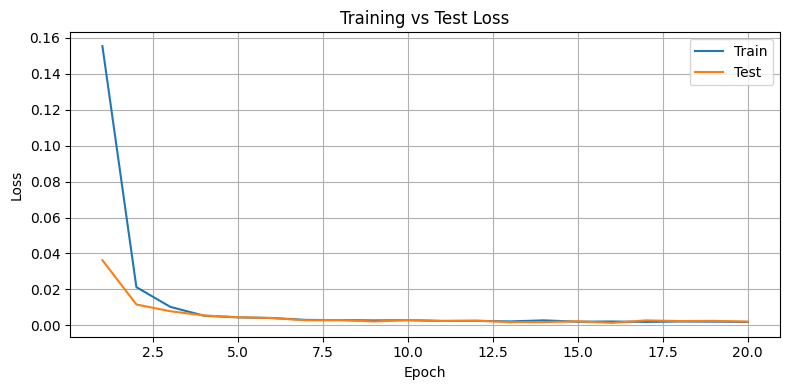

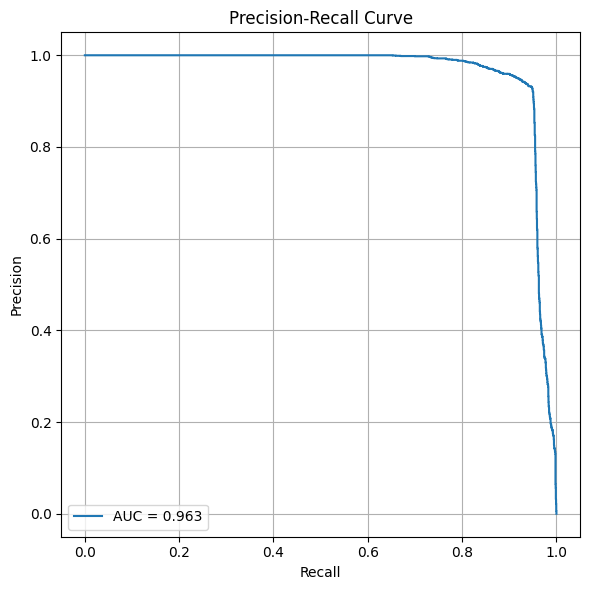

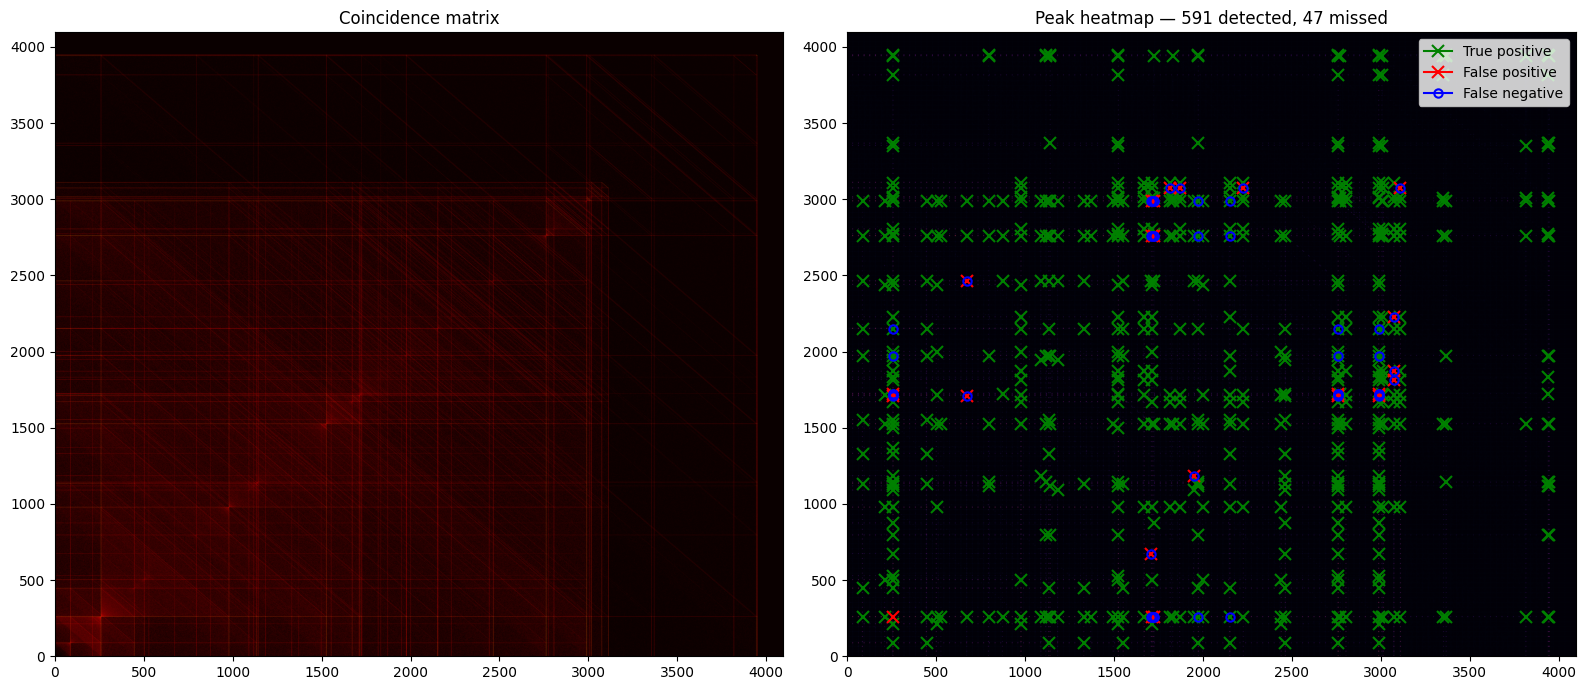

In [117]:
if __name__ == "__main__":
    model = run_training(
        data_dir = "../../data",
        n_epochs = 20,
        batch_size = 32,
        lr = 1e-3,
        patches_per_mat = 100,
        n_matrices = None, # None = use all files found
        save_path = "peak_detector.pt",
    )

    with open("yy_coincidence_matrix.mat", "rb") as f:
        mat = pickle.load(f)

    with open("yy_coincidence_matrix_clean.mat", "rb") as f:
        clean_mat = pickle.load(f)

    peaks, heatmap = detect_peaks(
        model,
        mat,
        patch_size = PATCH_SIZE,
        stride = 32,
        threshold = 0.5,
        min_peak_pixels = 2,
    )

    rows, cols = np.where(clean_mat > 0)
    true_peaks = list(zip(rows.tolist(), cols.tolist()))
    
    true_positives, false_positives, false_negatives = classify_peaks(peaks, true_peaks, tolerance=0)

    print_coincidences(peaks)
    plot_results(mat, heatmap, true_positives, false_positives, false_negatives)

### Experimenting

#### Creating new function to classify peaks that are 'close enough'

In [118]:
def classify_peaks_close(detected_peaks, true_peaks, tolerance=0):
    """
    Classifies detected peaks as true positives or false positives,
    and identifies false negatives (missed true peaks).

    tolerance : max pixel distance to count as a match
    """
    true_peaks_arr = np.array(true_peaks) if true_peaks else np.empty((0, 2))
    detected_peaks_arr = np.array(detected_peaks) if detected_peaks else np.empty((0, 2))

    matched_true = set()
    det_to_true_idx = {}
    true_positives = []
    closer_positives = []
    false_positives = []

    '''for det in detected_peaks:
        if len(true_peaks_arr) == 0:
            false_positives.append(det)
            continue

        # Find closest true peak to this detection
        dists = np.sqrt(((true_peaks_arr - np.array(det)) ** 2).sum(axis=1))
        nearest_idx = dists.argmin()

        if dists[nearest_idx] <= tolerance and nearest_idx not in matched_true and dists[nearest_idx] == 0:
            true_positives.append(det)
            matched_true.add(nearest_idx)
        elif dists[nearest_idx] <= tolerance and nearest_idx not in matched_true:
            closer_positives.append(det)
            matched_true.add(nearest_idx) 
        else:
            false_positives.append(det)

    # Any true peak not matched is a false negative
    false_negatives = [true_peaks[i] for i in range(len(true_peaks)) if i not in matched_true]'''

    for i, det in enumerate(detected_peaks):
        if len(true_peaks_arr) == 0:
            false_positives.append(det)
            continue

        dists = np.sqrt(((true_peaks_arr - np.array(det)) ** 2).sum(axis=1))
        nearest_idx = dists.argmin()

        if dists[nearest_idx] <= tolerance and nearest_idx not in matched_true and dists[nearest_idx] == 0:
            true_positives.append(det)
            matched_true.add(nearest_idx)
            det_to_true_idx[i] = nearest_idx
        elif dists[nearest_idx] <= tolerance and nearest_idx not in matched_true:
            closer_positives.append(det)
            matched_true.add(nearest_idx)
            det_to_true_idx[i] = nearest_idx
        else:
            false_positives.append(det)

    false_negatives = [true_peaks[i] for i in range(len(true_peaks)) if i not in matched_true]

    print(f"True positives:  {len(true_positives)}")
    print(f"True (Enough) positives: {len(closer_positives)}")
    print(f"False Positives: {len(false_positives)}")
    print(f"False negatives: {len(false_negatives)}")

    if false_positives:
        print("\nFalse positive locations (detected but not real):")
        for r, c in sorted(false_positives):
            print(f"  ({r}, {c})")

    if false_negatives:
        print("\nFalse negative locations (real but not detected):")
        for r, c in sorted(false_negatives):
            print(f"  ({r}, {c})")

    if closer_positives:
        print(f"\nClose positive locations (detected but off by {tolerance} or less pixels):")
        for r,c in sorted(closer_positives):
            print(f"  ({r}, {c})")

    return true_positives, false_positives, false_negatives, closer_positives, det_to_true_idx

In [119]:
true_pos, false_pos, false_neg, closer_pos, det_to_true_idx = classify_peaks_close(peaks, true_peaks, tolerance=10)

True positives:  567
True (Enough) positives: 23
False Positives: 1
False negatives: 24

False positive locations (detected but not real):
  (257, 258)

False negative locations (real but not detected):
  (258, 1708)
  (258, 1724)
  (258, 1974)
  (258, 2150)
  (1708, 258)
  (1708, 2759)
  (1708, 2987)
  (1724, 258)
  (1724, 2759)
  (1724, 2987)
  (1974, 258)
  (1974, 2759)
  (1974, 2987)
  (2150, 258)
  (2150, 2759)
  (2150, 2987)
  (2759, 1708)
  (2759, 1724)
  (2759, 1974)
  (2759, 2150)
  (2987, 1708)
  (2987, 1724)
  (2987, 1974)
  (2987, 2150)

Close positive locations (detected but off by 10 or less pixels):
  (258, 1711)
  (258, 1723)
  (673, 1708)
  (1182, 1947)
  (1708, 673)
  (1711, 258)
  (1711, 2759)
  (1711, 2987)
  (1723, 258)
  (1723, 2759)
  (1723, 2987)
  (1815, 3073)
  (1869, 3073)
  (2226, 3073)
  (2461, 672)
  (2759, 1711)
  (2759, 1723)
  (2987, 1711)
  (2987, 1723)
  (3073, 1815)
  (3073, 1869)
  (3073, 2226)
  (3073, 3109)


In [120]:
def categorize_false_negatives(false_negatives, detected_peaks, true_peaks, merge_radius=3):
    detected_arr = np.array(detected_peaks) if detected_peaks else np.empty((0,2))

    merged = []
    missed = []

    for fn in false_negatives:
        if len(detected_arr) == 0:
            missed.append(fn)
            continue

        dists = np.sqrt(((detected_arr - np.array(fn)) ** 2).sum(axis=1))
        if dists.min() <= merge_radius:
            nearest_det = detected_peaks[dists.argmin()]
            merged.append((fn, nearest_det)) # missed true peak, nearby detection
        else:
            missed.append(fn)

    print(f"Merged (nearby detection existed: {len(merged)})")
    print(f"Truly missed (no nearby detection): {len(missed)}")

    if merged:
        print("\nMerged false negatives (true peak --> nearest detection):")
        for fn, det in merged:
            print(f"    true: {fn} --> detected: {det}")

    if missed:
        print("\nTruly missed peaks:")
        for r, c in sorted(missed):
            print(f"    ({r}, {c})")

    return merged, missed

In [121]:
merged, missed = categorize_false_negatives(false_neg, peaks, true_peaks, merge_radius=3)

Merged (nearby detection existed: 24)
Truly missed (no nearby detection): 0

Merged false negatives (true peak --> nearest detection):
    true: (258, 1708) --> detected: (258, 1711)
    true: (258, 1724) --> detected: (258, 1723)
    true: (258, 1974) --> detected: (258, 1973)
    true: (258, 2150) --> detected: (258, 2151)
    true: (1708, 258) --> detected: (1711, 258)
    true: (1708, 2759) --> detected: (1711, 2759)
    true: (1708, 2987) --> detected: (1711, 2987)
    true: (1724, 258) --> detected: (1723, 258)
    true: (1724, 2759) --> detected: (1723, 2759)
    true: (1724, 2987) --> detected: (1723, 2987)
    true: (1974, 258) --> detected: (1973, 258)
    true: (1974, 2759) --> detected: (1973, 2759)
    true: (1974, 2987) --> detected: (1973, 2987)
    true: (2150, 258) --> detected: (2151, 258)
    true: (2150, 2759) --> detected: (2151, 2759)
    true: (2150, 2987) --> detected: (2151, 2987)
    true: (2759, 1708) --> detected: (2759, 1711)
    true: (2759, 1724) --> dete

In [122]:
print(len(true_peaks))

614


In [123]:
def find_merged_pairs(false_negatives, detected_peaks, true_peaks, det_to_true_idx, merge_radius=3):
    """
    Returns pairs of true peaks that were merged into a single detection.
    Each entry: (true_peak_A, true_peak_B, detection_D)
      - D was matched to A
      - B is a false negative close to D
    """
    detected_arr = np.array(detected_peaks) if detected_peaks else np.empty((0, 2))
    merged_pairs = []

    # Build reverse map: true_peak_index -> detected_peak
    true_idx_to_det = {t_idx: detected_peaks[d_idx] for d_idx, t_idx in det_to_true_idx.items()}

    for fn in false_negatives:
        if len(detected_arr) == 0:
            continue

        dists = np.sqrt(((detected_arr - np.array(fn)) ** 2).sum(axis=1))
        nearest_det_idx = dists.argmin()

        if dists[nearest_det_idx] <= merge_radius:
            # Which true peak did this detection get matched to?
            matched_true_idx = det_to_true_idx.get(nearest_det_idx)
            if matched_true_idx is not None:
                true_peak_A = true_peaks[matched_true_idx]
                merged_pairs.append((true_peak_A, fn, detected_peaks[nearest_det_idx]))

    print(f"Merged pairs found: {len(merged_pairs)}")
    for A, B, D in merged_pairs:
        print(f"  true A: {A}  +  true B: {B}  →  detection: {D}")

    return merged_pairs

In [124]:
import sys

print(f"{'TRUE PEAKS':<20} {'DETECTED PEAKS':<20}")
print("-" * 40)
for i in range(max(len(true_peaks), len(peaks))):
    tp = f"({true_peaks[i][0]}, {true_peaks[i][1]})" if i < len(true_peaks) else ""
    dp = f"({peaks[i][0]}, {peaks[i][1]})"           if i < len(peaks)      else ""
    print(f"{tp:<20} {dp:<20}", file=sys.stderr)

TRUE PEAKS           DETECTED PEAKS      
----------------------------------------


(86, 258)            (86, 258)           
(86, 445)            (86, 445)           
(86, 1133)           (86, 1133)          
(86, 1330)           (86, 1330)          
(86, 1551)           (86, 1551)          
(86, 1974)           (86, 1974)          
(86, 2150)           (86, 2150)          
(86, 2462)           (86, 2462)          
(86, 2759)           (86, 2759)          
(86, 2987)           (86, 2987)          
(211, 258)           (211, 258)          
(211, 501)           (211, 501)          
(211, 977)           (211, 977)          
(211, 1524)          (211, 1524)         
(211, 1713)          (211, 1713)         
(211, 2439)          (211, 2439)         
(211, 2759)          (211, 2759)         
(211, 2987)          (211, 2987)         
(258, 86)            (258, 86)           
(258, 211)           (258, 211)          
(258, 445)           (257, 258)          
(258, 501)           (258, 445)          
(258, 527)           (258, 501)          
(258, 672)           (258, 527)   

In [125]:
print(true_peaks)

[(86, 258), (86, 445), (86, 1133), (86, 1330), (86, 1551), (86, 1974), (86, 2150), (86, 2462), (86, 2759), (86, 2987), (211, 258), (211, 501), (211, 977), (211, 1524), (211, 1713), (211, 2439), (211, 2759), (211, 2987), (258, 86), (258, 211), (258, 445), (258, 501), (258, 527), (258, 672), (258, 794), (258, 873), (258, 977), (258, 1089), (258, 1116), (258, 1133), (258, 1141), (258, 1183), (258, 1330), (258, 1369), (258, 1495), (258, 1524), (258, 1551), (258, 1669), (258, 1708), (258, 1713), (258, 1722), (258, 1724), (258, 1815), (258, 1830), (258, 1869), (258, 1947), (258, 1973), (258, 1974), (258, 1998), (258, 2150), (258, 2151), (258, 2226), (258, 2439), (258, 2462), (258, 2759), (258, 2771), (258, 2803), (258, 2987), (258, 3005), (258, 3014), (258, 3072), (258, 3109), (258, 3351), (258, 3366), (258, 3814), (258, 3940), (258, 3946), (445, 86), (445, 258), (445, 1133), (445, 1330), (445, 1551), (445, 1974), (445, 2150), (445, 2462), (445, 2759), (445, 2987), (501, 211), (501, 258), (5

In [126]:
merged_pairs = find_merged_pairs(false_negatives, peaks, true_peaks, det_to_true_idx, merge_radius=3)

Merged pairs found: 47
  true A: (258, 1713)  +  true B: (258, 1708)  →  detection: (258, 1711)
  true A: (258, 1713)  +  true B: (258, 1713)  →  detection: (258, 1711)
  true A: (258, 1722)  +  true B: (258, 1722)  →  detection: (258, 1723)
  true A: (258, 1722)  +  true B: (258, 1724)  →  detection: (258, 1723)
  true A: (258, 1973)  +  true B: (258, 1974)  →  detection: (258, 1973)
  true A: (258, 2151)  +  true B: (258, 2150)  →  detection: (258, 2151)
  true A: (672, 1708)  +  true B: (672, 1708)  →  detection: (673, 1708)
  true A: (1183, 1947)  +  true B: (1183, 1947)  →  detection: (1182, 1947)
  true A: (1713, 258)  +  true B: (1708, 258)  →  detection: (1711, 258)
  true A: (1708, 672)  +  true B: (1708, 672)  →  detection: (1708, 673)
  true A: (1713, 2759)  +  true B: (1708, 2759)  →  detection: (1711, 2759)
  true A: (1713, 2987)  +  true B: (1708, 2987)  →  detection: (1711, 2987)
  true A: (1713, 258)  +  true B: (1713, 258)  →  detection: (1711, 258)
  true A: (1713, 27

In [127]:
print(f"There are {len(false_negatives)} false negatives: ")
print(false_negatives)

There are 47 false negatives: 
[(258, 1708), (258, 1713), (258, 1722), (258, 1724), (258, 1974), (258, 2150), (672, 1708), (1183, 1947), (1708, 258), (1708, 672), (1708, 2759), (1708, 2987), (1713, 258), (1713, 2759), (1713, 2987), (1722, 258), (1722, 2759), (1722, 2987), (1724, 258), (1724, 2759), (1724, 2987), (1815, 3072), (1869, 3072), (1974, 258), (1974, 2759), (1974, 2987), (2150, 258), (2150, 2759), (2150, 2987), (2226, 3072), (2462, 672), (2759, 1708), (2759, 1713), (2759, 1722), (2759, 1724), (2759, 1974), (2759, 2150), (2987, 1708), (2987, 1713), (2987, 1722), (2987, 1724), (2987, 1974), (2987, 2150), (3072, 1815), (3072, 1869), (3072, 2226), (3072, 3109)]


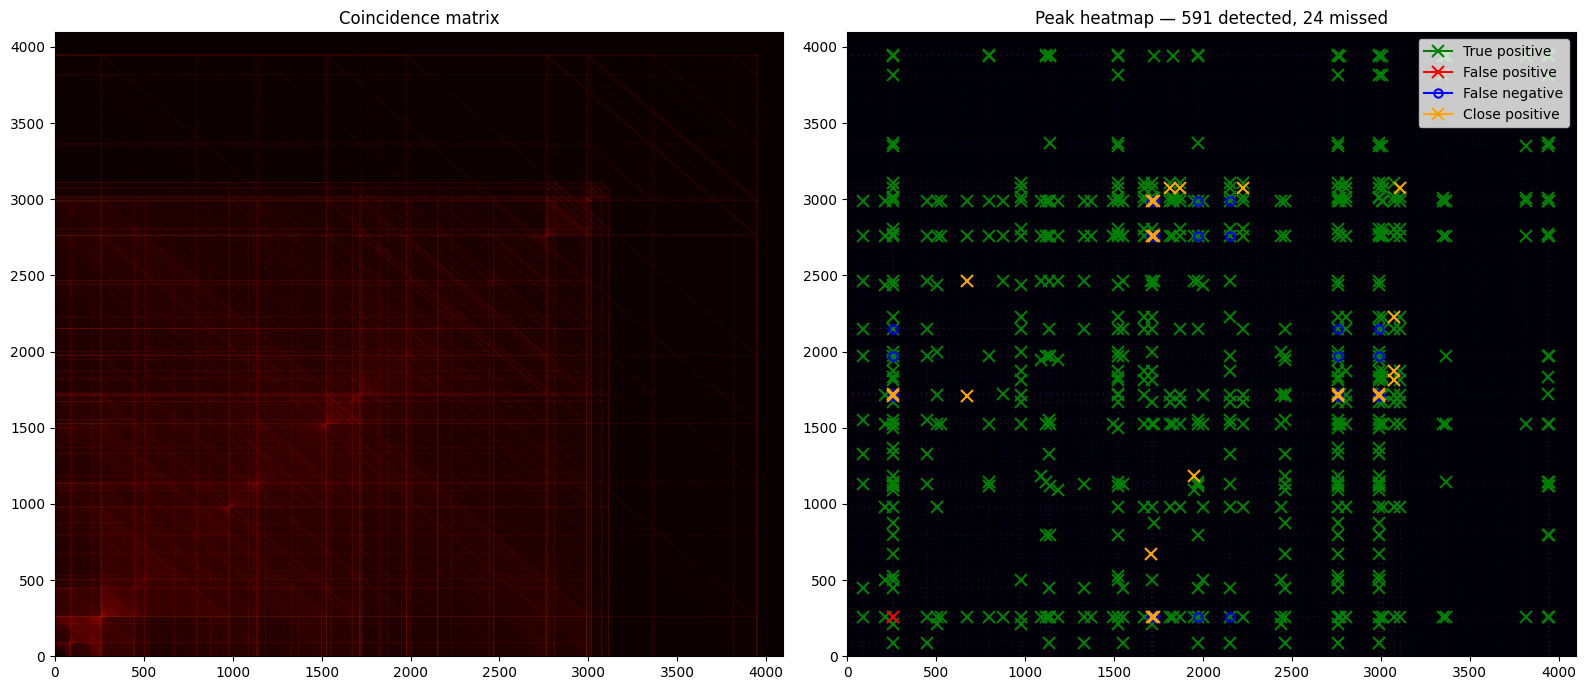

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.imshow(np.log1p(mat), cmap='hot', origin='lower', aspect='auto')
ax.set_title("Coincidence matrix")

ax = axes[1]
ax.imshow(heatmap, cmap='inferno', origin='lower', aspect='auto',
          norm=mcolors.PowerNorm(gamma=0.5))

for r, c in true_pos:
    ax.plot(c, r, marker='x', color='green', markersize=8, markeredgewidth=1.5, label='True positive')
for r, c in false_pos:
    ax.plot(c, r, marker='x', color='red', markersize=8, markeredgewidth=1.5, label='False positive')
for r, c in false_neg:
    ax.plot(c, r, marker='o', color='blue', markersize=6, markeredgewidth=1.5,
            fillstyle='none', label='False negative')
for r, c in closer_pos:
    ax.plot(c, r, marker='x', color='orange', markersize=8, markeredgewidth=1.5, label='Close positive')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

n_detected = len(true_positives) + len(false_positives)
ax.set_title(f"Peak heatmap — {n_detected} detected, {len(false_neg)} missed")

plt.tight_layout()

In [129]:
n_peaks = np.count_nonzero(clean_mat)
n_peaks

np.int64(614)

True positives:  590
False positives: 1
False negatives: 24

False positive locations (detected but not real):
  (257, 258)

False negative locations (real but not detected):
  (258, 1708)
  (258, 1724)
  (258, 1974)
  (258, 2150)
  (1708, 258)
  (1708, 2759)
  (1708, 2987)
  (1724, 258)
  (1724, 2759)
  (1724, 2987)
  (1974, 258)
  (1974, 2759)
  (1974, 2987)
  (2150, 258)
  (2150, 2759)
  (2150, 2987)
  (2759, 1708)
  (2759, 1724)
  (2759, 1974)
  (2759, 2150)
  (2987, 1708)
  (2987, 1724)
  (2987, 1974)
  (2987, 2150)

Coincidences:
86: [258, 445, 1133, 1330, 1551, 1974, 2150, 2462, 2759, 2987]
211: [258, 501, 977, 1524, 1713, 2439, 2759, 2987]
257: [258]
258: [86, 211, 257, 445, 501, 527, 672, 794, 873, 977, 1089, 1116, 1133, 1141, 1183, 1330, 1369, 1495, 1524, 1551, 1669, 1711, 1723, 1815, 1830, 1869, 1947, 1973, 1998, 2151, 2226, 2439, 2462, 2759, 2771, 2803, 2987, 3005, 3014, 3072, 3109, 3351, 3366, 3814, 3940, 3946]
445: [86, 258, 1133, 1330, 1551, 1974, 2150, 2462, 2759, 2987]

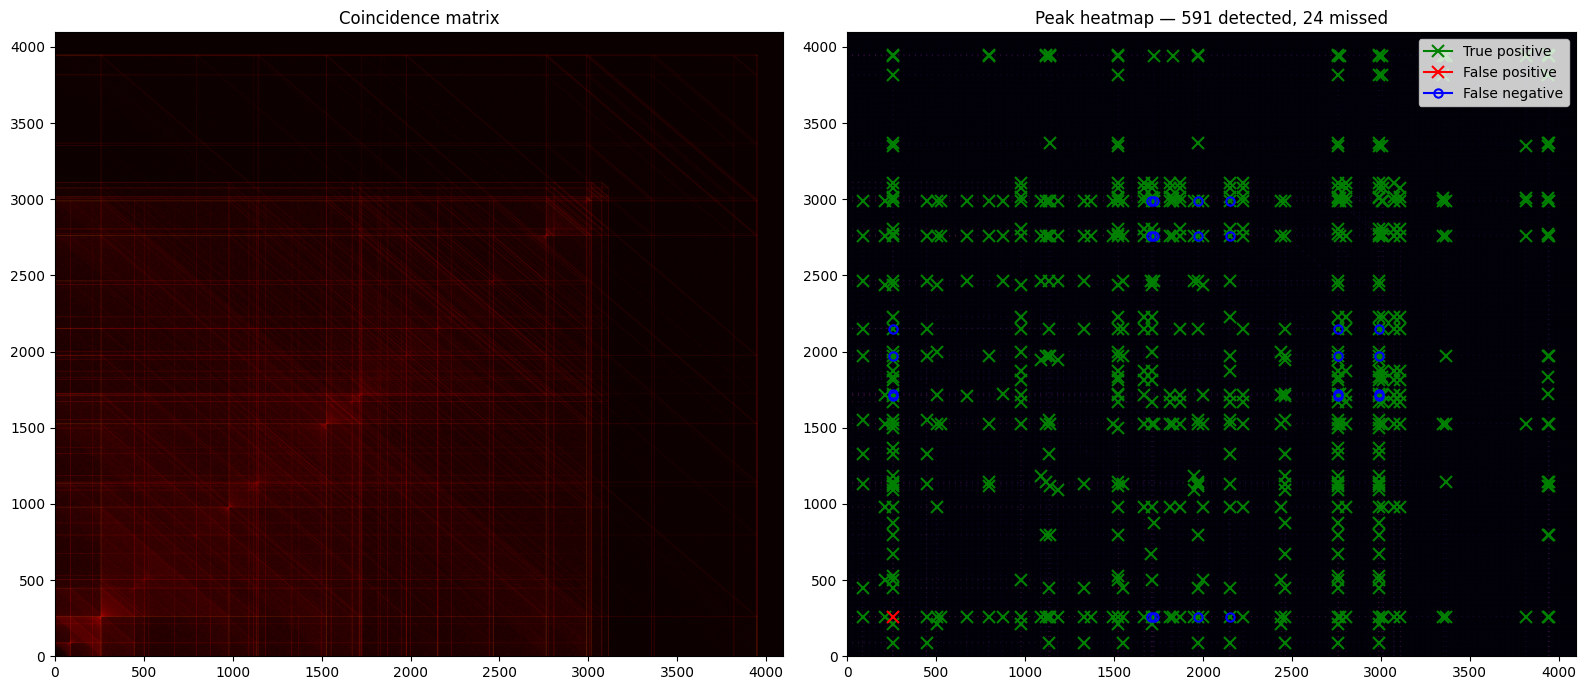

In [130]:
rows, cols = np.where(clean_mat > 0)
true_peaks = list(zip(rows.tolist(), cols.tolist()))
    
true_positives, false_positives, false_negatives = classify_peaks(peaks, true_peaks, tolerance=10)

print_coincidences(peaks)
plot_results(mat, heatmap, true_positives, false_positives, false_negatives)

### Pre-Processing

In [131]:
mat_log = np.log1p(mat)
mat_n = mat_log / mat_log.max()
print(f"After log+norm — min: {mat_n.min():.3f}, max: {mat_n.max():.3f}")

After log+norm — min: 0.000, max: 1.000


In [132]:
pad = PATCH_SIZE // 2
mat_padded = np.pad(mat_n, pad, mode='reflect')
print(f"Original: {mat_n.shape} → Padded: {mat_padded.shape} (pad={pad} on each side)")

Original: (4096, 4096) → Padded: (4160, 4160) (pad=32 on each side)


In [133]:
device = torch.device('cuda' if torch.cuda.is_available() 
                      else 'mps' if torch.backends.mps.is_available() 
                      else 'cpu')
print(f"Using device: {device}")

Using device: mps


### Showing how the U-Net Works

### Showing matrix at each U-Net layer

In [134]:
def visualize_unet_internals(model, mat_n, clean_mat, patch_size=64, n_channels_shown=8):
    """
    Registers hooks on every U-Net stage, runs one patch through, and plots:
      Figure 1 — mean activation at every stage (shows spatial reduction)
      Figure 2 — first n_channels_shown individual feature maps per stage
    """
    device = next(model.parameters()).device
    model.eval()

    pad        = patch_size // 2
    mat_padded = np.pad(mat_n, pad, mode='reflect')

    true_peaks = get_true_peaks(clean_mat)
    if true_peaks:
        pr, pc = true_peaks[len(true_peaks) // 2]
        r0 = max(0, min((pr + pad) - patch_size // 2, mat_padded.shape[0] - patch_size))
        c0 = max(0, min((pc + pad) - patch_size // 2, mat_padded.shape[1] - patch_size))
    else:
        r0 = mat_padded.shape[0] // 2 - patch_size // 2
        c0 = mat_padded.shape[1] // 2 - patch_size // 2

    patch = mat_padded[r0:r0+patch_size, c0:c0+patch_size]

    activations = {}
    hooks       = []

    def make_hook(name):
        def hook(module, inp, out):
            activations[name] = out.detach().cpu()
        return hook

    for i, down in enumerate(model.downs):
        hooks.append(down.register_forward_hook(make_hook(f'enc_{i}')))

    hooks.append(model.bottleneck.register_forward_hook(make_hook('bottleneck')))

    for i in range(1, len(model.ups), 2):
        hooks.append(model.ups[i].register_forward_hook(make_hook(f'dec_{i // 2}')))

    with torch.no_grad():
        x      = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)
        output = model(x)
        activations['output'] = torch.sigmoid(output).detach().cpu()

    for h in hooks:
        h.remove()

    input_tensor = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0)

    stages = [
        ('Input\n1 ch · 64×64',          input_tensor),
        ('Encoder 1\n32 ch · 64×64',     activations['enc_0']),
        ('Encoder 2\n64 ch · 32×32',     activations['enc_1']),
        ('Encoder 3\n128 ch · 16×16',    activations['enc_2']),
        ('Encoder 4\n256 ch · 8×8',      activations['enc_3']),
        ('Bottleneck\n512 ch · 4×4',     activations['bottleneck']),
        ('Decoder 1\n256 ch · 8×8',      activations['dec_0']),
        ('Decoder 2\n128 ch · 16×16',    activations['dec_1']),
        ('Decoder 3\n64 ch · 32×32',     activations['dec_2']),
        ('Decoder 4\n32 ch · 64×64',     activations['dec_3']),
        ('Output (sigmoid)\n1 ch · 64×64', activations['output']),
    ]

    stage_filenames = [
        'unet_stage_00_input',
        'unet_stage_01_encoder1',
        'unet_stage_02_encoder2',
        'unet_stage_03_encoder3',
        'unet_stage_04_encoder4',
        'unet_stage_05_bottleneck',
        'unet_stage_06_decoder1',
        'unet_stage_07_decoder2',
        'unet_stage_08_decoder3',
        'unet_stage_09_decoder4',
        'unet_stage_10_output',
    ]

    for (title, act), fname in zip(stages, stage_filenames):
        a      = act.squeeze().numpy()
        mean_a = a if a.ndim == 2 else a.mean(axis=0)
        n_ch   = 1 if a.ndim == 2 else a.shape[0]
        h, w   = mean_a.shape

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(mean_a, cmap='hot', origin='lower', aspect='auto')
        ax.set_title(title.replace('\n', '  |  '), fontsize=13)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(f"{fname}.png", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved → {fname}.png")


    stage_keys = [
        ('enc_0',      'Encoder 1  —  32 ch · 64×64'),
        ('enc_1',      'Encoder 2  —  64 ch · 32×32'),
        ('enc_2',      'Encoder 3  — 128 ch · 16×16'),
        ('enc_3',      'Encoder 4  — 256 ch · 8×8'),
        ('bottleneck', 'Bottleneck — 512 ch · 4×4'),
        ('dec_0',      'Decoder 1  — 256 ch · 8×8'),
        ('dec_1',      'Decoder 2  — 128 ch · 16×16'),
        ('dec_2',      'Decoder 3  —  64 ch · 32×32'),
        ('dec_3',      'Decoder 4  —  32 ch · 64×64'),
    ]

    n_cols  = n_channels_shown + 1
    n_rows  = len(stage_keys)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.8))
    fig.suptitle(f"U-Net Feature Channels at Each Stage  (mean + first {n_channels_shown} channels)",
                 fontsize=13, fontweight='bold', color='white')
    fig.patch.set_facecolor('#1e1e1e')

    for row, (key, label) in enumerate(stage_keys):
        act   = activations[key].squeeze().numpy()
        n_ch  = act.shape[0]
        mean_a = act.mean(axis=0)

        axes[row, 0].imshow(mean_a, cmap='inferno', origin='lower', aspect='auto')
        axes[row, 0].set_ylabel(label, fontsize=7, color='white',
                                rotation=0, ha='right', va='center', labelpad=4)
        axes[row, 0].set_title("mean", fontsize=7, color='#aaa')
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

        for col in range(n_channels_shown):
            ax = axes[row, col + 1]
            if col < n_ch:
                ax.imshow(act[col], cmap='inferno', origin='lower', aspect='auto')
                ax.set_title(f"ch {col}", fontsize=7, color='#aaa')
            else:
                ax.axis('off')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_facecolor('#111')

    plt.tight_layout()
    plt.savefig("unet_internals_channels.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → unet_internals_channels.png\n")

    return activations

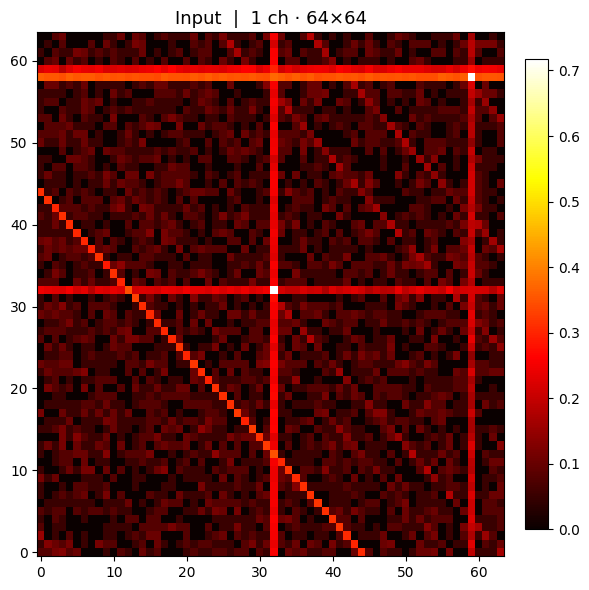

Saved → unet_stage_00_input.png


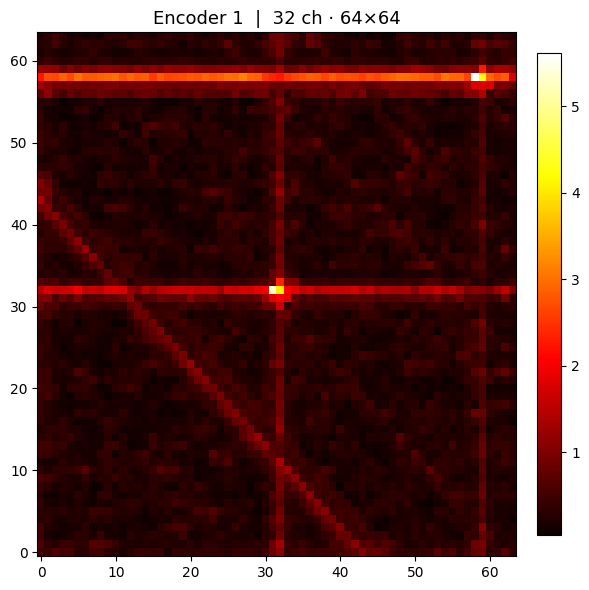

Saved → unet_stage_01_encoder1.png


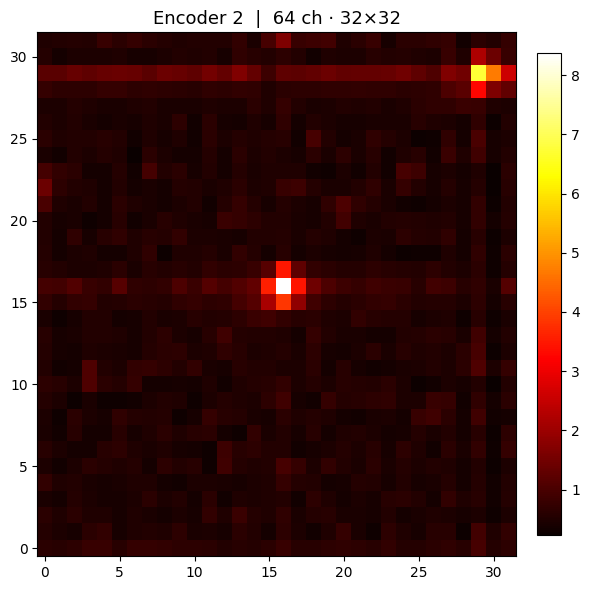

Saved → unet_stage_02_encoder2.png


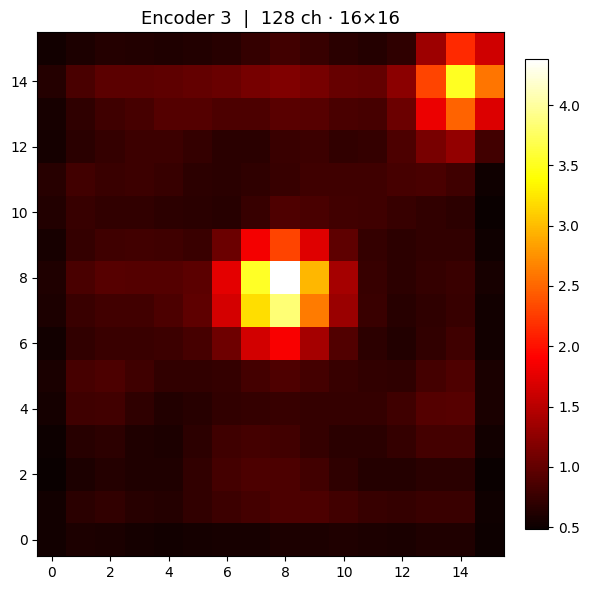

Saved → unet_stage_03_encoder3.png


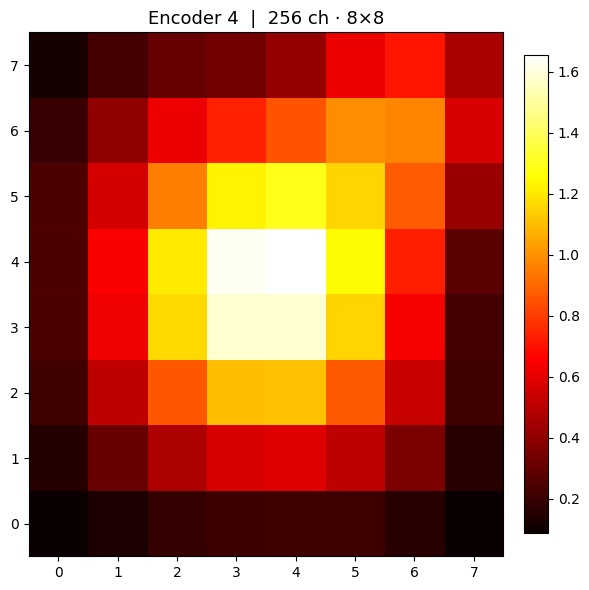

Saved → unet_stage_04_encoder4.png


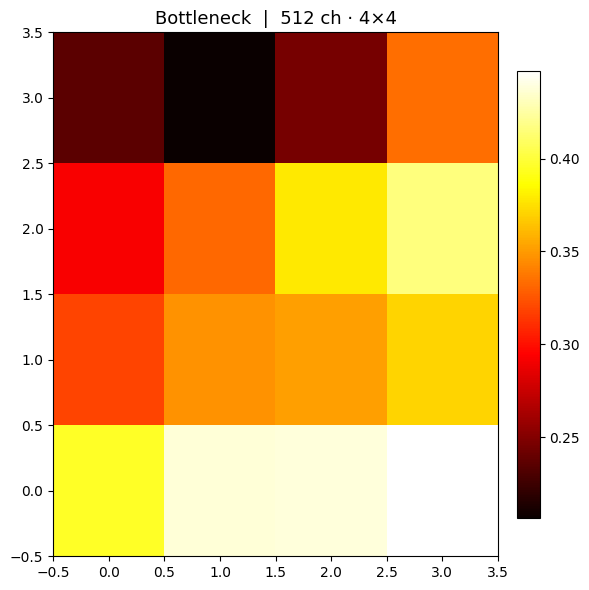

Saved → unet_stage_05_bottleneck.png


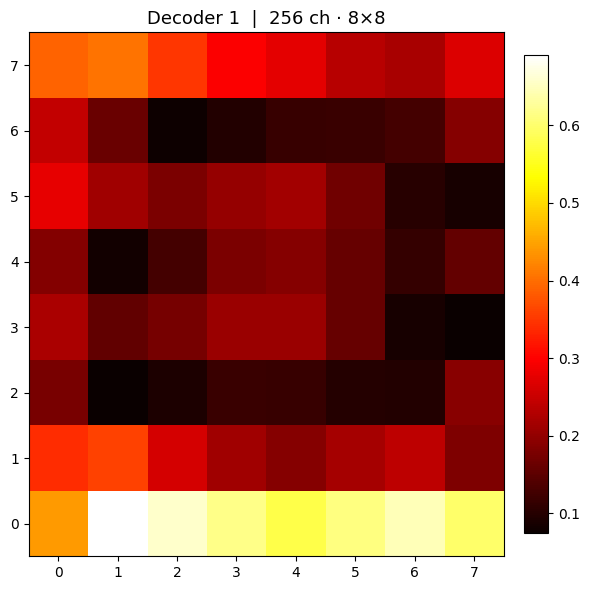

Saved → unet_stage_06_decoder1.png


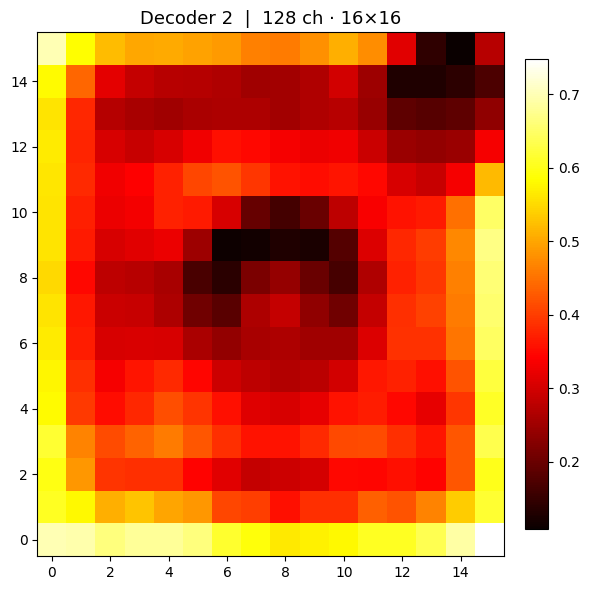

Saved → unet_stage_07_decoder2.png


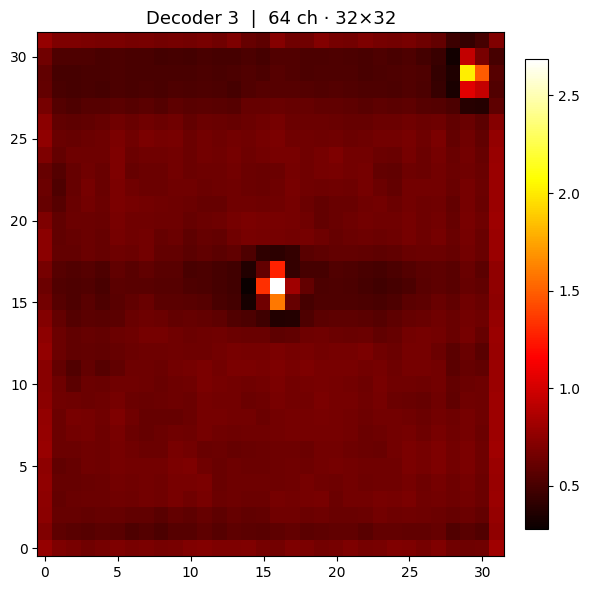

Saved → unet_stage_08_decoder3.png


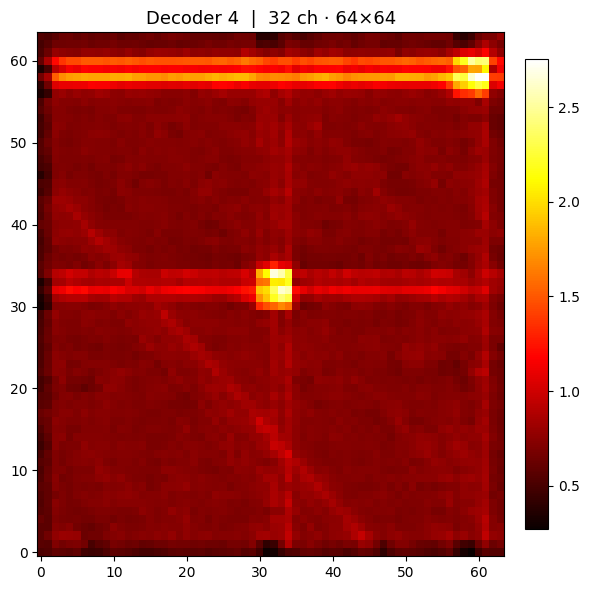

Saved → unet_stage_09_decoder4.png


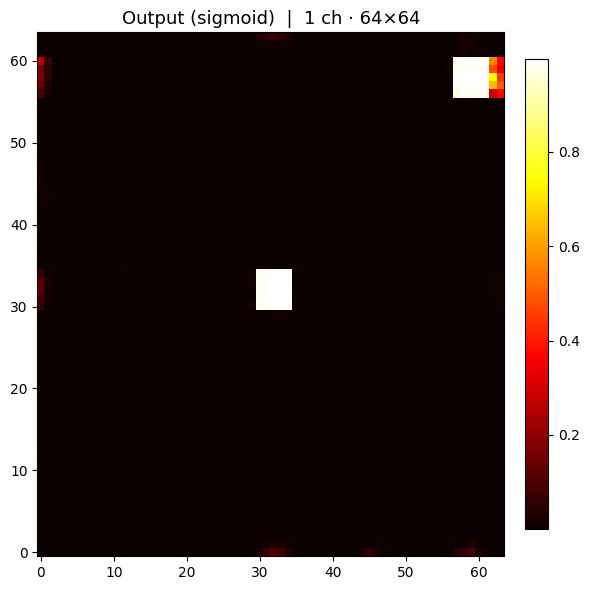

Saved → unet_stage_10_output.png


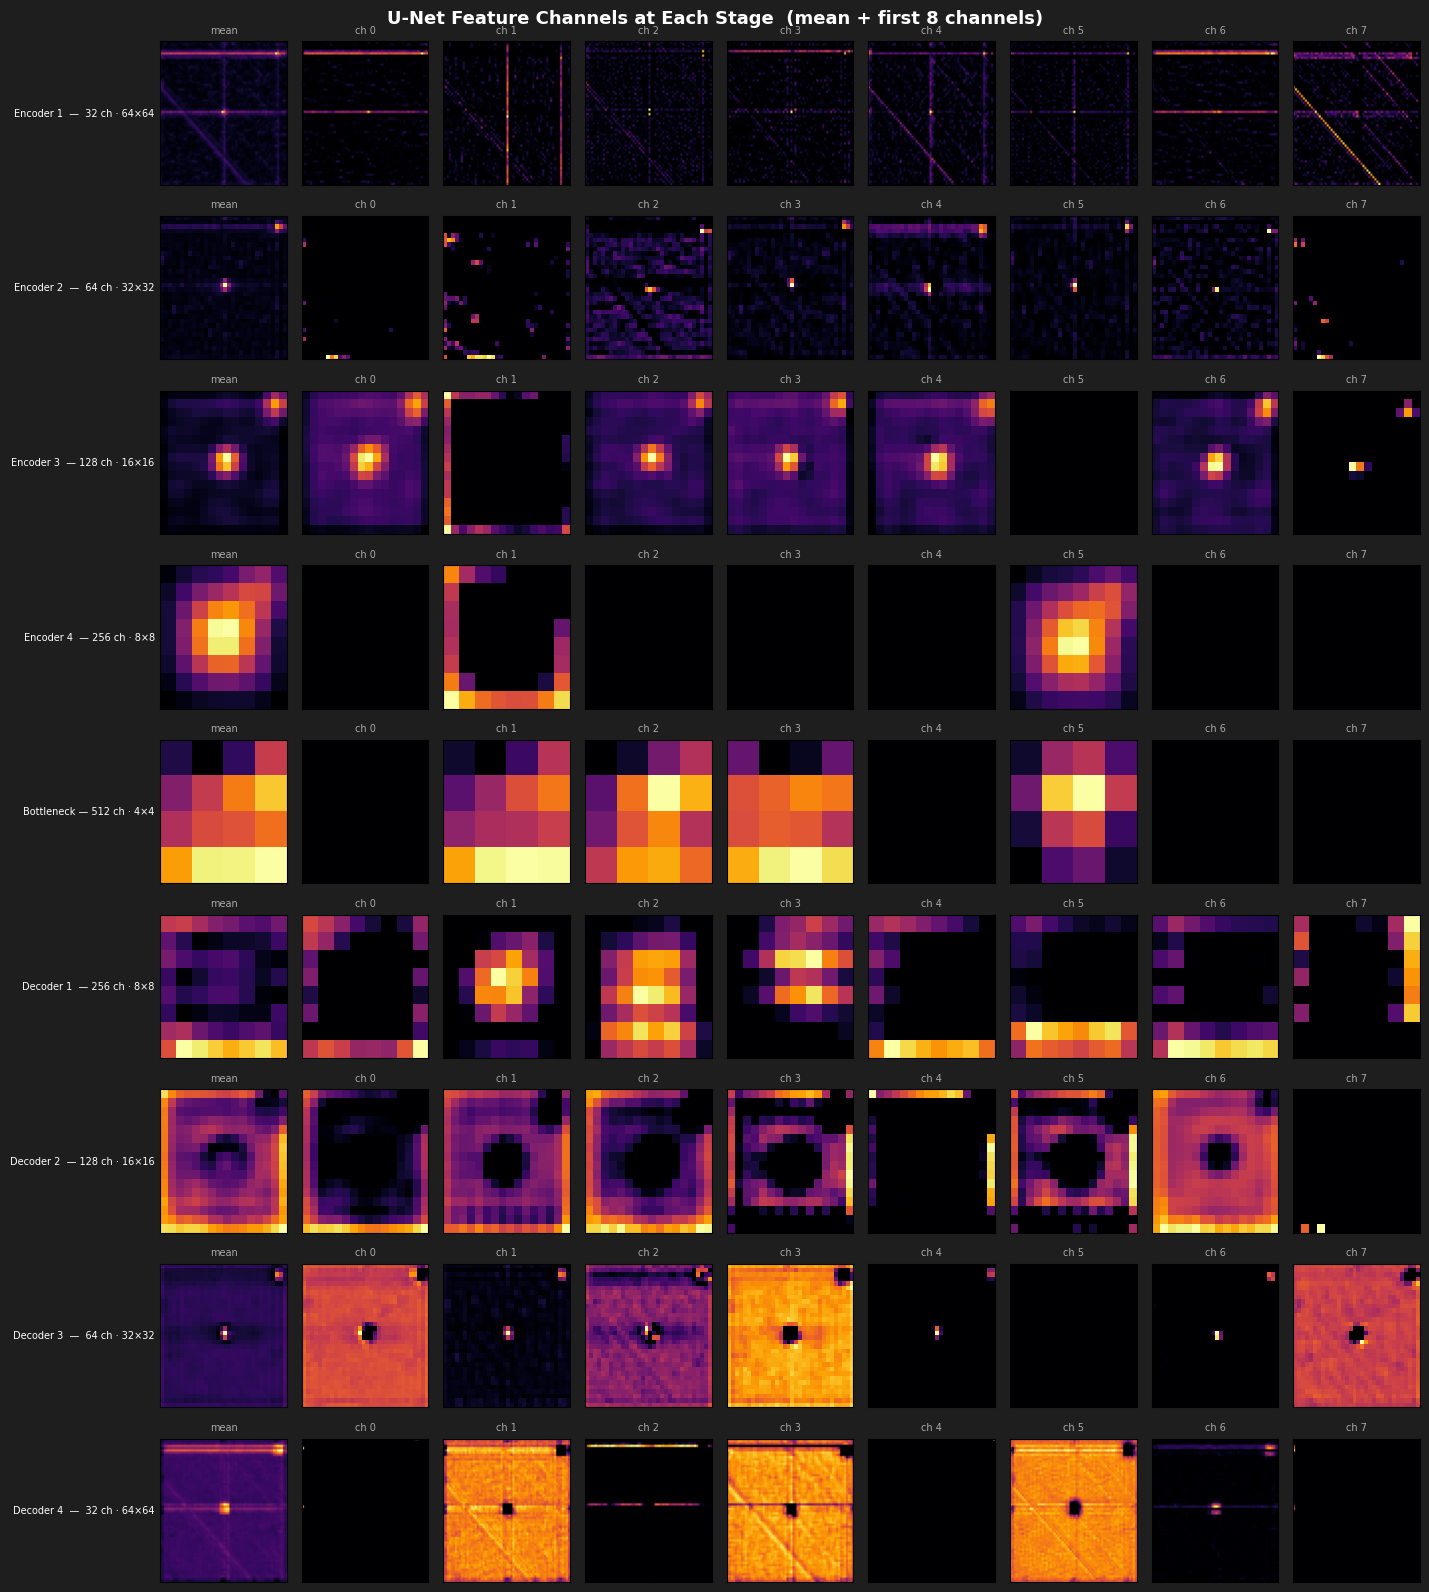

Saved → unet_internals_channels.png



In [135]:
activations = visualize_unet_internals(model, mat_n, clean_mat, n_channels_shown=8)

### Diagnositcs

In [136]:
def recall_by_separation(true_peaks, detected_peaks, tolerance=2, bins=range(0, 30, 2)):
    true_arr = np.array(true_peaks)
    det_arr  = np.array(detected_peaks)

    # For each true peak, find its distance to the nearest OTHER true peak
    separations = []
    detected    = []
    for i, tp in enumerate(true_arr):
        others = np.delete(true_arr, i, axis=0)
        min_sep = np.sqrt(((others - tp)**2).sum(axis=1)).min() if len(others) else 999

        # Was this peak detected?
        dists_to_det = np.sqrt(((det_arr - tp)**2).sum(axis=1))
        hit = dists_to_det.min() <= tolerance if len(det_arr) else False

        separations.append(min_sep)
        detected.append(hit)

    separations = np.array(separations)
    detected    = np.array(detected)

    recalls, centers = [], []
    for lo in bins:
        hi = lo + 2
        mask = (separations >= lo) & (separations < hi)
        if mask.sum() > 0:
            recalls.append(detected[mask].mean())
            centers.append(lo + 1)

    plt.figure(figsize=(8, 4))
    plt.bar(centers, recalls, width=1.8, edgecolor='black')
    plt.axhline(1.0, color='green', linestyle='--', label='Perfect recall')
    plt.xlabel("Distance to nearest other true peak (pixels)")
    plt.ylabel("Recall")
    plt.title("CNN Recall vs. Peak Separation")
    plt.legend(); plt.tight_layout()
    plt.savefig("recall_vs_separation.png", dpi=150)

In [137]:
def recall_by_separation(true_peaks, detected_peaks, tolerance=2, bins=range(0, 30, 2)):
    true_arr = np.array(true_peaks)
    det_arr  = np.array(detected_peaks)

    separations = []
    detected    = []
    for i, tp in enumerate(true_arr):
        others = np.delete(true_arr, i, axis=0)
        min_sep = np.sqrt(((others - tp)**2).sum(axis=1)).min() if len(others) else 999

        dists_to_det = np.sqrt(((det_arr - tp)**2).sum(axis=1))
        hit = dists_to_det.min() <= tolerance if len(det_arr) else False

        separations.append(min_sep)
        detected.append(hit)

    separations = np.array(separations)
    detected    = np.array(detected)

    recalls, centers = [], []
    for lo in bins:
        hi = lo + 2
        mask = (separations >= lo) & (separations < hi)
        if mask.sum() > 0:
            recalls.append(detected[mask].mean())
            centers.append(lo + 1)

    plt.figure(figsize=(8, 4))
    plt.bar(centers, recalls, width=1.8, edgecolor='black')
    plt.axhline(1.0, color='green', linestyle='--', label='Perfect recall')
    plt.xlabel("Distance to nearest other true peak (pixels)")
    plt.ylabel("Recall")
    plt.title("CNN Recall vs. Peak Separation")
    plt.legend(); plt.tight_layout()
    plt.savefig("recall_vs_separation.png", dpi=150)


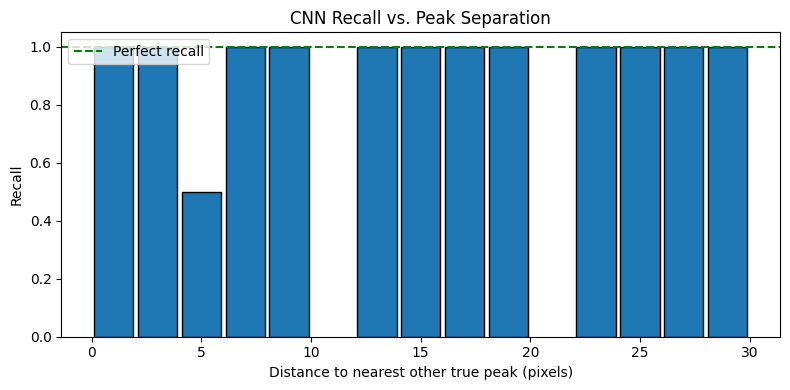

In [138]:
recall_by_separation(true_peaks, peaks)

In [139]:
def plot_heatmap_crosssection(heatmap, peak_a, peak_b, axis='row'):
    """
    peak_a, peak_b: (row, col) of two nearby true peaks
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: 2D heatmap zoomed around the two peaks
    margin = 15
    r0 = max(0, min(peak_a[0], peak_b[0]) - margin)
    r1 = min(heatmap.shape[0], max(peak_a[0], peak_b[0]) + margin)
    c0 = max(0, min(peak_a[1], peak_b[1]) - margin)
    c1 = min(heatmap.shape[1], max(peak_a[1], peak_b[1]) + margin)

    axes[0].imshow(heatmap[r0:r1, c0:c1], cmap='inferno', origin='lower')
    axes[0].plot(peak_a[1]-c0, peak_a[0]-r0, 'b+', markersize=12, label='True peak A')
    axes[0].plot(peak_b[1]-c0, peak_b[0]-r0, 'g+', markersize=12, label='True peak B')
    axes[0].set_title("Heatmap (zoomed)")
    axes[0].legend()

    # Right: 1D slice — if two peaks merged, you'll see ONE bump, not two
    mid_row = (peak_a[0] + peak_b[0]) // 2
    axes[1].plot(heatmap[mid_row, c0:c1])
    axes[1].axvline(peak_a[1]-c0, color='blue', linestyle='--', label='True peak A')
    axes[1].axvline(peak_b[1]-c0, color='green', linestyle='--', label='True peak B')
    axes[1].set_xlabel("Column (pixels)")
    axes[1].set_ylabel("CNN probability")
    axes[1].set_title("1D heatmap slice — one bump = peaks merged")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("crosssection_merged.png", dpi=150)


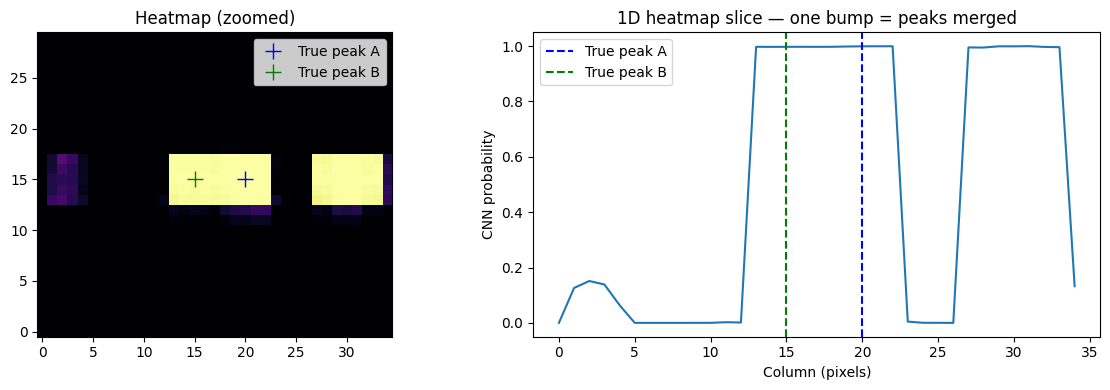

In [140]:
plot_heatmap_crosssection(heatmap, peak_a=(258, 1713), peak_b=(258, 1708))

### Max Filtering

In [141]:
def detect_peaks(model, mat, patch_size=PATCH_SIZE, stride=32,
                 threshold=0.7, min_peak_pixels=4, min_distance=10):
    """
    Sliding-window CNN inference with hybrid post-processing:
      1. Threshold heatmap into blobs, suppresses background noise
      2. Find local maxima within each blob,  attempts to split merged peaks
    """
    device = next(model.parameters()).device
    model.eval()

    size    = mat.shape[0]
    mat_log = np.log1p(mat)
    mx      = mat_log.max()
    mat_n   = (mat_log / mx).astype(np.float32) if mx > 0 else mat_log

    pad = patch_size // 2
    mat_padded = np.pad(mat_n, pad, mode='reflect')
    pad_size = mat_padded.shape[0]

    heatmap_padded = np.zeros((pad_size, pad_size), dtype=np.float32)
    count_padded = np.zeros((pad_size, pad_size), dtype=np.float32)

    rows = list(range(0, pad_size - patch_size, stride)) + [pad_size - patch_size]
    cols = list(range(0, pad_size - patch_size, stride)) + [pad_size - patch_size]

    with torch.no_grad():
        for r in rows:
            for c in cols:
                patch = mat_padded[r:r+patch_size, c:c+patch_size]
                x = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
                heatmap_padded[r:r+patch_size, c:c+patch_size] += prob
                count_padded[r:r+patch_size, c:c+patch_size] += 1

    heatmap_padded /= np.maximum(count_padded, 1)
    heatmap = heatmap_padded[pad:pad+size, pad:pad+size]

    binary, _ = label(heatmap > threshold)
    objects   = find_objects(binary)

    peaks = []
    for obj in objects:
        r_sl, c_sl = obj
        mask   = (binary[r_sl, c_sl] > 0).astype(np.float32)
        region = heatmap[r_sl, c_sl] * mask

        if mask.sum() < min_peak_pixels:
            continue

        local_max = (region == maximum_filter(region, size=min_distance)) & (region > 0)
        for r, c in np.argwhere(local_max):
            peaks.append((r + r_sl.start, c + c_sl.start))

    print(f"Detected {len(peaks)} peaks (threshold={threshold})")
    return peaks, heatmap


Device: mps

Loading 100 matrix pairs from ../../data/NonBlurredArrays
 Loaded pair 0
 Loaded pair 1
 Loaded pair 10
 Loaded pair 11
 Loaded pair 12
 Loaded pair 13
 Loaded pair 14
 Loaded pair 15
 Loaded pair 16
 Loaded pair 17
 Loaded pair 18
 Loaded pair 19
 Loaded pair 2
 Loaded pair 20
 Loaded pair 21
 Loaded pair 22
 Loaded pair 23
 Loaded pair 24
 Loaded pair 25
 Loaded pair 26
 Loaded pair 27
 Loaded pair 28
 Loaded pair 29
 Loaded pair 3
 Loaded pair 30
 Loaded pair 31
 Loaded pair 32
 Loaded pair 33
 Loaded pair 34
 Loaded pair 35
 Loaded pair 36
 Loaded pair 37
 Loaded pair 38
 Loaded pair 39
 Loaded pair 4
 Loaded pair 40
 Loaded pair 41
 Loaded pair 42
 Loaded pair 43
 Loaded pair 44
 Loaded pair 45
 Loaded pair 46
 Loaded pair 47
 Loaded pair 48
 Loaded pair 49
 Loaded pair 5
 Loaded pair 50
 Loaded pair 51
 Loaded pair 52
 Loaded pair 53
 Loaded pair 54
 Loaded pair 55
 Loaded pair 56
 Loaded pair 57
 Loaded pair 58
 Loaded pair 59
 Loaded pair 6
 Loaded pair 60
 Loaded 

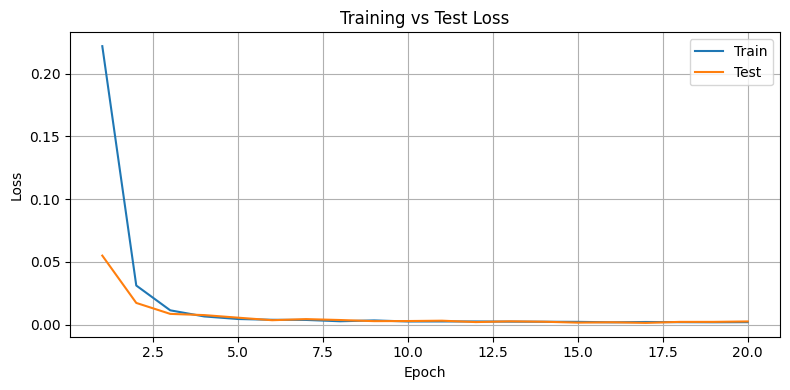

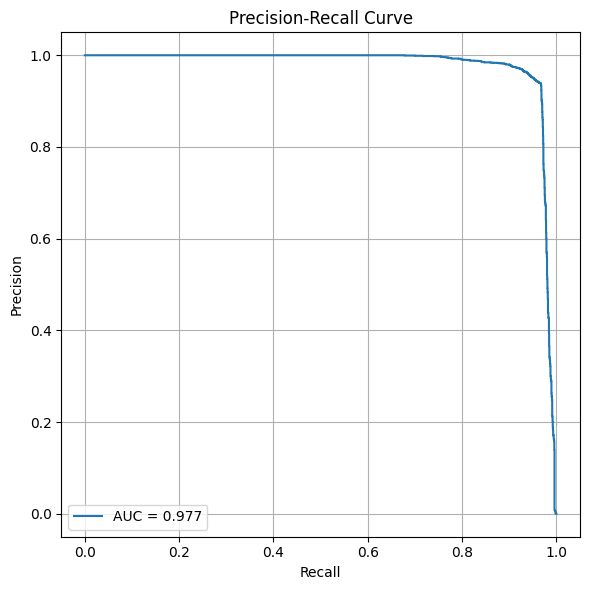

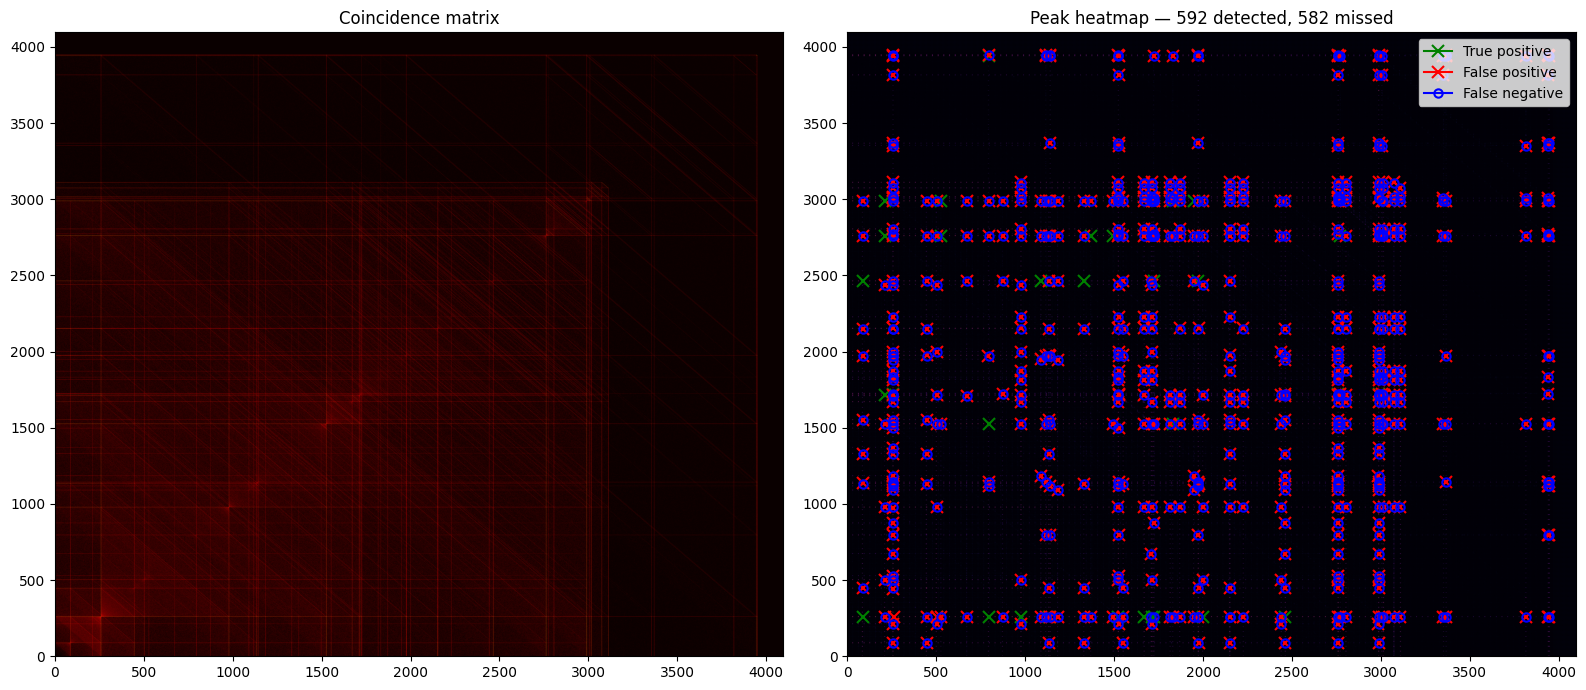

In [142]:
if __name__ == "__main__":
    model = run_training(
        data_dir = "../../data",
        n_epochs = 20,
        batch_size = 32,
        lr = 1e-3,
        patches_per_mat = 100,
        n_matrices = None, # None = use all files found
        save_path = "peak_detector.pt",
    )

    with open("yy_coincidence_matrix.mat", "rb") as f:
        mat = pickle.load(f)

    with open("yy_coincidence_matrix_clean.mat", "rb") as f:
        clean_mat = pickle.load(f)

    peaks, heatmap = detect_peaks(
        model,
        mat,
        patch_size = PATCH_SIZE,
        stride = 32,
        threshold = 0.5,
        min_peak_pixels = 2,
    )

    rows, cols = np.where(clean_mat > 0)
    true_peaks = list(zip(rows.tolist(), cols.tolist()))
    
    true_positives, false_positives, false_negatives = classify_peaks(peaks, true_peaks, tolerance=0)

    print_coincidences(peaks)
    plot_results(mat, heatmap, true_positives, false_positives, false_negatives)

In [143]:
true_pos, false_pos, false_neg, closer_pos, det_to_true_idx = classify_peaks_close(peaks, true_peaks, tolerance=5)

True positives:  32
True (Enough) positives: 558
False Positives: 2
False negatives: 24

False positive locations (detected but not real):
  (256, 260)
  (259, 501)

False negative locations (real but not detected):
  (258, 1708)
  (258, 1724)
  (258, 1974)
  (258, 2151)
  (1708, 258)
  (1708, 2759)
  (1708, 2987)
  (1722, 258)
  (1722, 2759)
  (1722, 2987)
  (1973, 2759)
  (1974, 258)
  (1974, 2987)
  (2150, 258)
  (2150, 2759)
  (2150, 2987)
  (2759, 1708)
  (2759, 1724)
  (2759, 1974)
  (2759, 2150)
  (2987, 1708)
  (2987, 1724)
  (2987, 1973)
  (2987, 2151)

Close positive locations (detected but off by 5 or less pixels):
  (86, 259)
  (86, 446)
  (86, 1134)
  (86, 1552)
  (86, 1975)
  (86, 2463)
  (86, 2760)
  (86, 2988)
  (87, 1330)
  (87, 2150)
  (211, 259)
  (211, 978)
  (211, 1525)
  (211, 2440)
  (211, 2760)
  (211, 2986)
  (212, 501)
  (212, 1713)
  (258, 1182)
  (258, 1496)
  (258, 1816)
  (258, 1948)
  (258, 2440)
  (258, 2760)
  (258, 2772)
  (258, 2804)
  (258, 2988)
  (

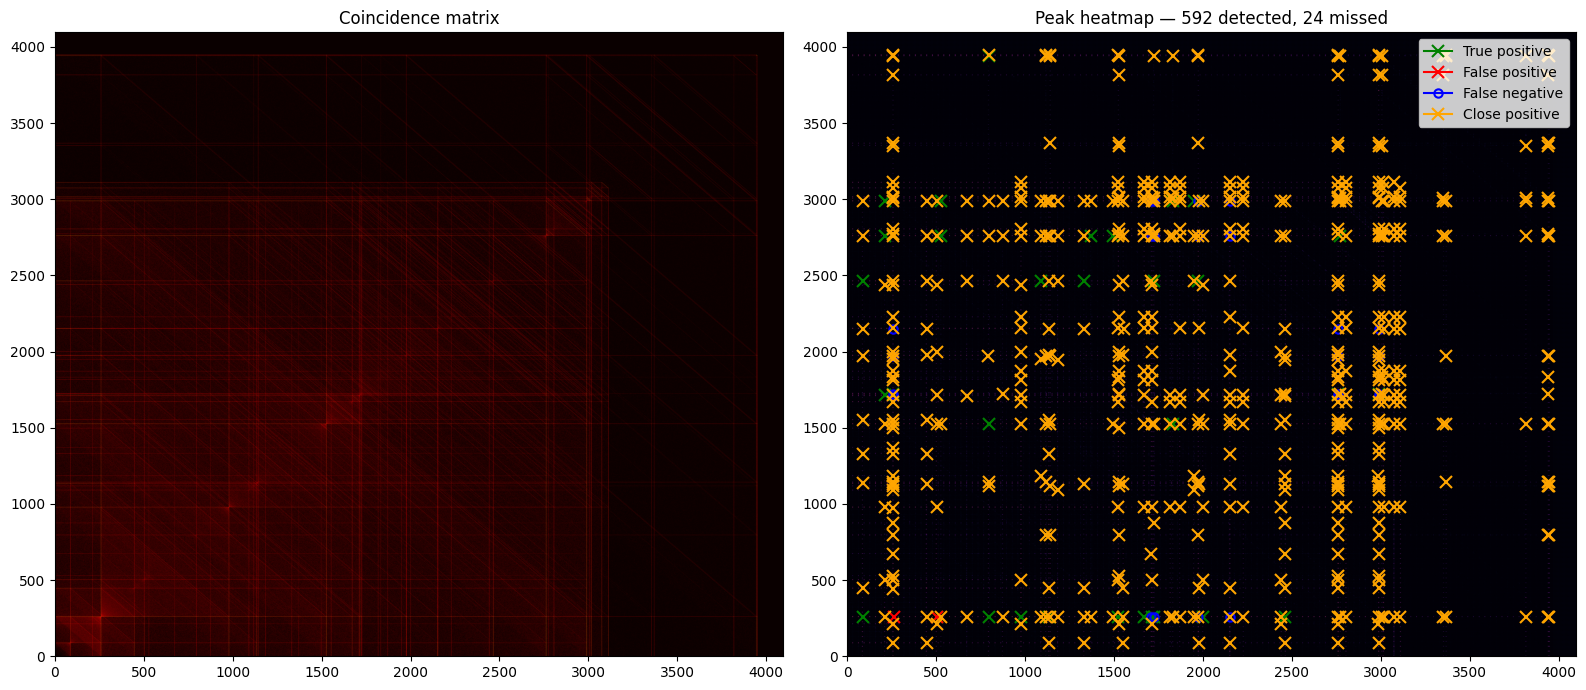

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.imshow(np.log1p(mat), cmap='hot', origin='lower', aspect='auto')
ax.set_title("Coincidence matrix")

ax = axes[1]
ax.imshow(heatmap, cmap='inferno', origin='lower', aspect='auto',
          norm=mcolors.PowerNorm(gamma=0.5))

for r, c in true_pos:
    ax.plot(c, r, marker='x', color='green', markersize=8, markeredgewidth=1.5, label='True positive')
for r, c in false_pos:
    ax.plot(c, r, marker='x', color='red', markersize=8, markeredgewidth=1.5, label='False positive')
for r, c in false_neg:
    ax.plot(c, r, marker='o', color='blue', markersize=6, markeredgewidth=1.5,
            fillstyle='none', label='False negative')
for r, c in closer_pos:
    ax.plot(c, r, marker='x', color='orange', markersize=8, markeredgewidth=1.5, label='Close positive')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

n_detected = len(true_positives) + len(false_positives)
ax.set_title(f"Peak heatmap — {n_detected} detected, {len(false_neg)} missed")

plt.tight_layout()

In [145]:
def plot_maxfilter_zoom(heatmap, peak_a, peak_b, min_distance=5, 
                        threshold=0.7, min_peak_pixels=4, margin=20):
    """
    Visualises what max filter detects around two nearby true peaks.
    Shows both the 2D heatmap and a 1D cross-section through the peaks' row.

    peak_a, peak_b : (row, col) of the two true peaks
    """
    r0 = max(0, min(peak_a[0], peak_b[0]) - margin)
    r1 = min(heatmap.shape[0], max(peak_a[0], peak_b[0]) + margin)
    c0 = max(0, min(peak_a[1], peak_b[1]) - margin)
    c1 = min(heatmap.shape[1], max(peak_a[1], peak_b[1]) + margin)

    zoom = heatmap[r0:r1, c0:c1]

    binary, _ = label(zoom > threshold)
    objects   = find_objects(binary)

    detected = []
    for obj in objects:
        rs, cs = obj
        mask = (binary[rs, cs] > 0).astype(np.float32)
        blob = zoom[rs, cs] * mask
        if mask.sum() < min_peak_pixels:
            continue
        local_max = (blob == maximum_filter(blob, size=min_distance)) & (blob > 0)
        for r, c in np.argwhere(local_max):
            detected.append((r + rs.start + r0, c + cs.start + c0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.imshow(zoom, cmap='inferno', origin='lower', aspect='auto',
              extent=[c0, c1, r0, r1])

    ax.plot(peak_a[1], peak_a[0], 'b+', markersize=16, markeredgewidth=2.5,
            label=f'True peak A  {peak_a}')
    ax.plot(peak_b[1], peak_b[0], 'g+', markersize=16, markeredgewidth=2.5,
            label=f'True peak B  {peak_b}')

    for i, (r, c) in enumerate(detected):
        label_str = 'Max filter detection' if i == 0 else ''
        ax.plot(c, r, 'ro', markersize=12, markeredgewidth=2,
                fillstyle='none', label=label_str)

    sep = abs(peak_b[1] - peak_a[1])
    ax.set_title(f'Heatmap (zoomed)')
    ax.legend(loc='upper right')

    ax = axes[1]
    shared_row = (peak_a[0] + peak_b[0]) // 2
    col_range  = np.arange(c0, c1)
    probs      = heatmap[shared_row, c0:c1]

    ax.plot(col_range, probs, color='orange', linewidth=2, label='CNN probability')
    ax.axhline(threshold, color='grey', linestyle='--', linewidth=1,
               label=f'Threshold ({threshold})')

    ax.axvline(peak_a[1], color='blue', linestyle='--', linewidth=1.5,
               label=f'True peak A ({peak_a[1]})')
    ax.axvline(peak_b[1], color='green', linestyle='--', linewidth=1.5,
               label=f'True peak B ({peak_b[1]})')

    for r, c in detected:
        ax.axvline(c, color='red', linestyle=':', linewidth=1.5,
                   label=f'Detected ({c})')

    ax.set_title(f'1D cross-section at row {shared_row}')
    ax.set_ylabel('CNN probability')
    ax.legend(loc='upper right')

    plt.suptitle('Max filter peak detection — merged peaks case', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('maxfilter_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Detected {len(detected)} peak(s): {detected}")
    print(f"True peaks: A={peak_a}, B={peak_b}")


Detected 606 peaks (threshold=0.7)


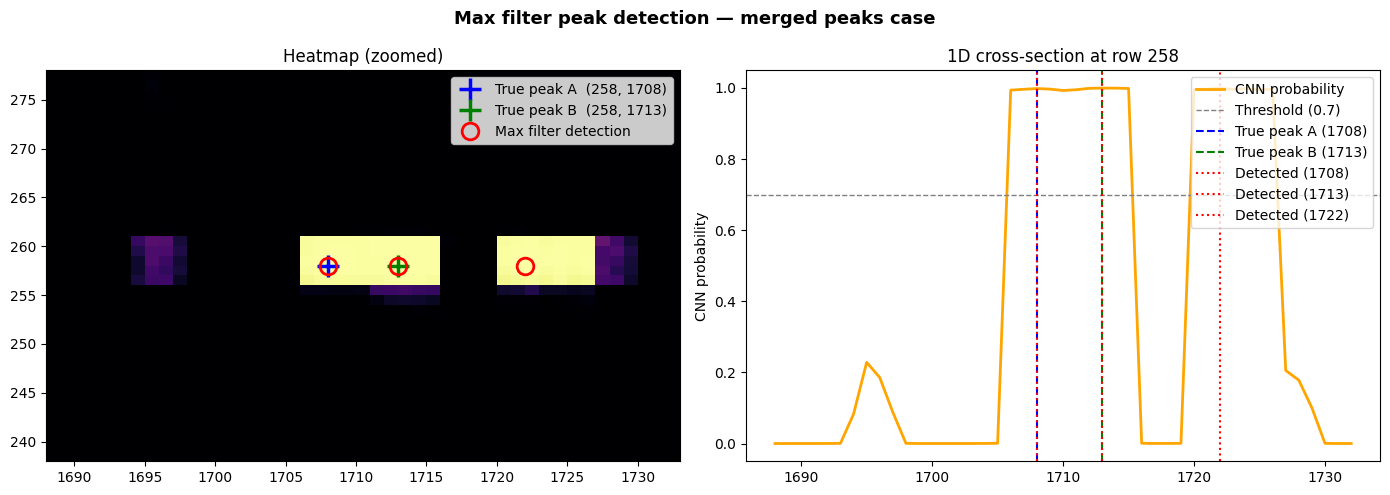

Detected 3 peak(s): [(np.int64(258), np.int64(1708)), (np.int64(258), np.int64(1713)), (np.int64(258), np.int64(1722))]
True peaks: A=(258, 1708), B=(258, 1713)


In [146]:
peaks, heatmap = detect_peaks(model, mat, threshold=0.7, min_distance=5)
plot_maxfilter_zoom(heatmap, peak_a=(258, 1708), peak_b=(258, 1713))

In [147]:
def evaluate_detection(detected_peaks, true_peaks, tolerances=(0, 1, 2, 3)):
    """
    Computes precision, recall, and F1 at multiple tolerance levels.
    Shows how much the method relies on generous matching to look good.
    """
    true_arr = np.array(true_peaks)
    det_arr  = np.array(detected_peaks) if detected_peaks else np.empty((0, 2))

    print(f"{'Tolerance':>10} {'TP':>6} {'FP':>6} {'FN':>6} "
          f"{'Precision':>10} {'Recall':>8} {'F1':>8}")
    print("-" * 60)

    for tol in tolerances:
        matched_true = set()
        tp, fp = 0, 0

        for det in detected_peaks:
            if len(true_arr) == 0:
                fp += 1
                continue
            dists = np.sqrt(((true_arr - np.array(det))**2).sum(axis=1))
            nearest = dists.argmin()
            if dists[nearest] <= tol and nearest not in matched_true:
                tp += 1
                matched_true.add(nearest)
            else:
                fp += 1

        fn        = len(true_peaks) - len(matched_true)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)

        print(f"{tol:>10}px {tp:>6} {fp:>6} {fn:>6} "
              f"{precision:>10.3f} {recall:>8.3f} {f1:>8.3f}")

    print(f"\nTotal detections : {len(detected_peaks)}")
    print(f"Total true peaks : {len(true_peaks)}")
    print(f"Detection ratio  : {len(detected_peaks)/len(true_peaks):.1f}x "
          f"({'over' if len(detected_peaks) > len(true_peaks) else 'under'}counting)")


In [148]:
evaluate_detection(peaks, true_peaks)

 Tolerance     TP     FP     FN  Precision   Recall       F1
------------------------------------------------------------
         0px     33    573    581      0.054    0.054    0.054
         1px    558     48     56      0.921    0.909    0.915
         2px    590     16     24      0.974    0.961    0.967
         3px    602      4     12      0.993    0.980    0.987

Total detections : 606
Total true peaks : 614
Detection ratio  : 1.0x (undercounting)


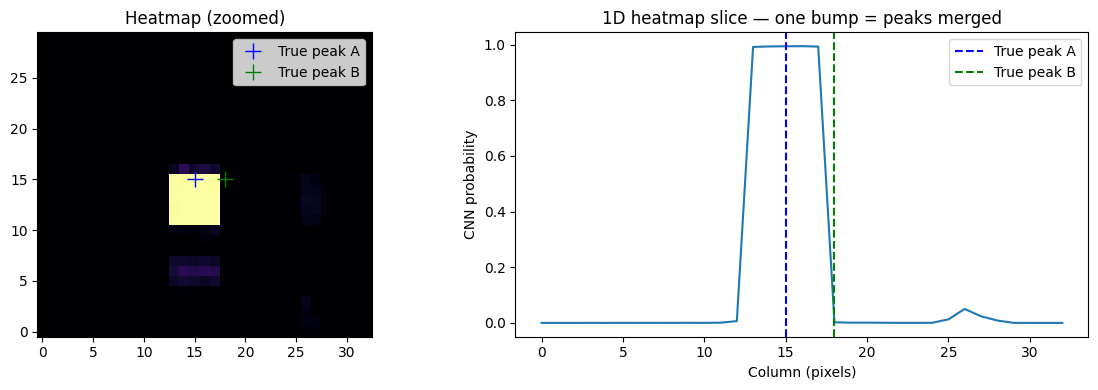

In [149]:
plot_heatmap_crosssection(heatmap, peak_a=(2441, 1524), peak_b=(2441, 1527))

Detected 606 peaks (threshold=0.7)


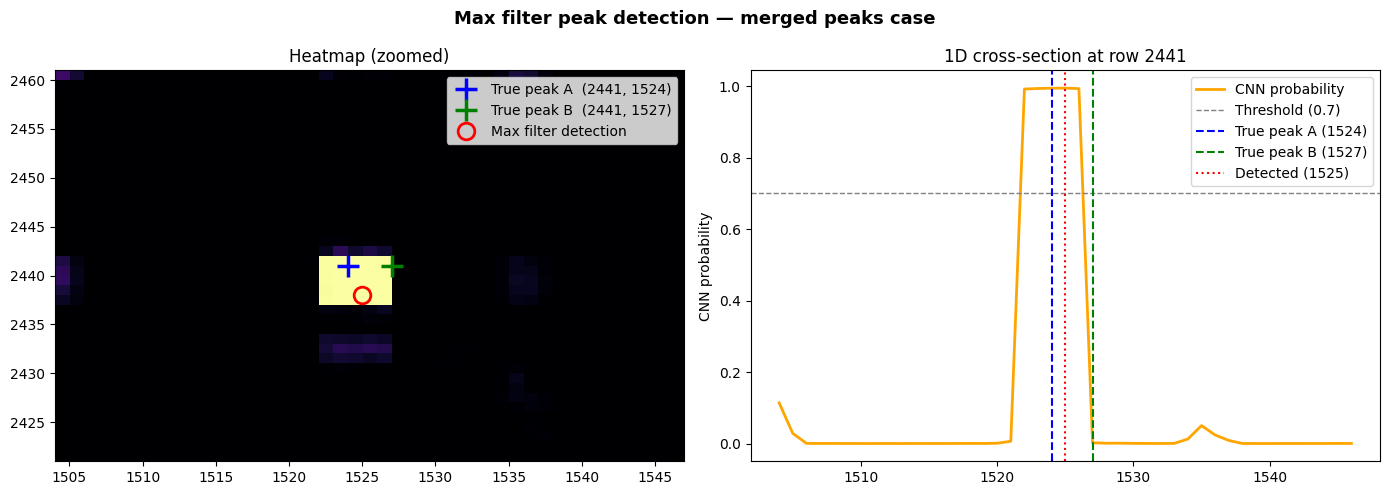

Detected 1 peak(s): [(np.int64(2438), np.int64(1525))]
True peaks: A=(2441, 1524), B=(2441, 1527)


In [150]:
peaks, heatmap = detect_peaks(model, mat, threshold=0.7, min_distance=5)
plot_maxfilter_zoom(heatmap, peak_a=(2441, 1524), peak_b=(2441, 1527))

Detected 606 peaks (threshold=0.7)


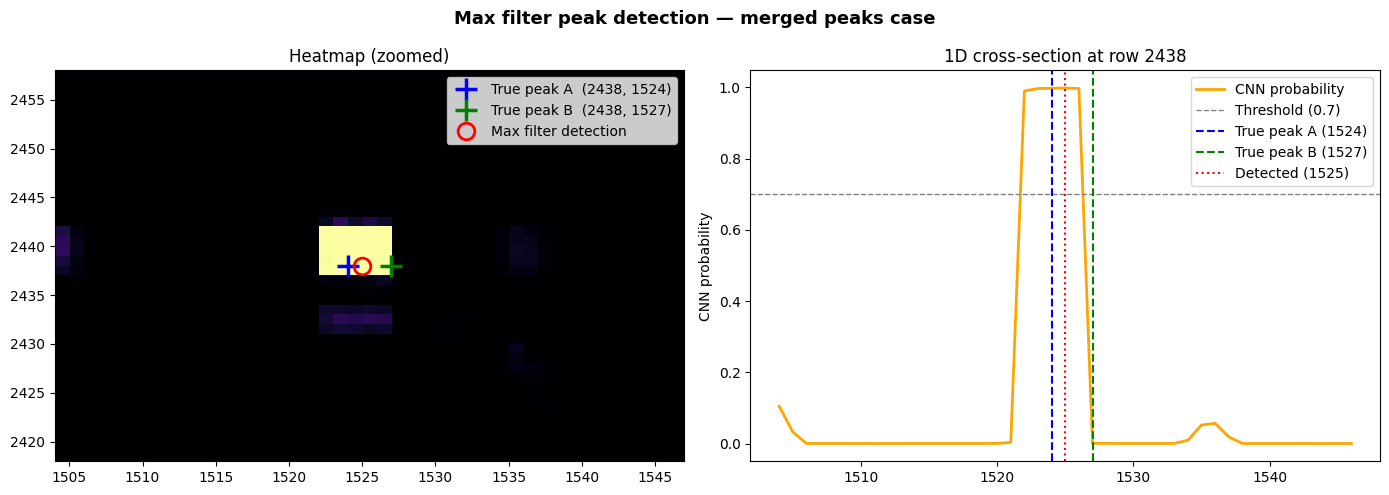

Detected 1 peak(s): [(np.int64(2438), np.int64(1525))]
True peaks: A=(2438, 1524), B=(2438, 1527)


In [151]:
peaks, heatmap = detect_peaks(model, mat, threshold=0.7, min_distance=5)
plot_maxfilter_zoom(heatmap, peak_a=(2438, 1524), peak_b=(2438, 1527))